In [1]:
# NOTE:
#  - this NB aims to model an observed source with bm
#  - here there is an improved version of the optimiser
#  - this is the same as `demo_sources_ebands_fit_benchmrk`, but in the full eband [2.0, 50.0] keV

# NOTE: this NB TESTS the efficiency of the FLEXIBLE implementations for SOURCE MODEL and IROS

from singleCAM_IROS._pipeline_support import _handle_dirpaths
from typing import Callable, Iterable
from pathlib import Path

from tqdm import tqdm
from numpy.typing import NDArray
import numpy as np

from bloodmoon.coords import shift2pos
from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import count

import darksun as ds

from flexible_IROS_rec_procedure import Source
from flexible_IROS_rec_procedure import iros_singleCAM
from flexible_source_model import model_shadowgram, model_sky


ds.show.set_figures_darkbkg()

In [ ]:
def config_psfy_flag(dataset: str) -> bool:
    if dataset not in ['detected', 'reconstructed']:
        raise ValueError('Invalid dataset type.')
    flag: bool = (True if DATASET == 'reconstructed' else False)
    return flag

MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

SKYFIELD: str = "IROSDummy"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_infdet_1ks"

ID_CAMERA_A: str = "cam1a"
DATASET: str = "detected"

UPS_X: int = 5
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = config_psfy_flag(DATASET)

In [3]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])

In [4]:
def _crop_inoptim(camera: CodedMaskCamera) -> tuple[int, int]:
    slit_fine, slit_coarse = ds.psf_extension(camera)
    crp = (
        slit_coarse + 5 * camera.upscale_f.y,
        slit_fine + 2 + camera.upscale_f.x,
    )
    return crp

PSF_CRP = _crop_inoptim(wfm)


def run(loop: Iterable) -> tuple[Source, ...]:
    """Runs the IROS loop."""
    print("# Running IROS loop...")
    candidates = tuple(cand for cand, _ in tqdm(loop))
    print("# End IROS loop...\n")
    return candidates

def plot_results(
    true_sky: NDArray,
    candidates: tuple[Source, ...],
    camera: CodedMaskCamera,
    varmap: NDArray | None = None,
    save_to: str | Path | None = None,
) -> None:
    """Plots energy band IROS results."""
    true_sky_ = true_sky.copy()
    std = np.sqrt(varmap)
    res_ground = np.zeros_like(true_sky_)
    for idx, cand in enumerate(candidates):
        pos: tuple[int, int] = shift2pos(camera, cand.shift_x, cand.shift_y)
        modeled: NDArray = model_sky(
            camera, cand.shift_x, cand.shift_y, cand.cts, VIGNETTING, PSFY,
        )
        sourceID: str = f'run_s{idx}'
        ds.slices_plot(
            sky=(true_sky_, modeled),
            pos=pos,
            crp=PSF_CRP,
            ylabel='counts [ph]',
            labels=('true', 'IROS'),
            color=('Orange', 'DeepSkyBlue'),
            source=sourceID,
            save_to=(
                ds.savefile_to(save_to, f'{sourceID.upper()}_profile')
                if save_to is not None else None
            ),
        )
        ds.slices_plot(
            sky=(res_ground, true_sky_ - modeled, std),
            pos=pos,
            crp=PSF_CRP,
            ylabel='residues',
            labels=['', 'true - IROS', 'local sigma'],
            color=('Orange', 'DeepSkyBlue', 'm'),
            source=sourceID,
            save_to=(
                ds.savefile_to(save_to, f'{sourceID.upper()}_profile_res')
                if save_to is not None else None
            ),
        )
        true_sky_ -= modeled

    return None

In [5]:
def comp_fit_weights(obs: NDArray) -> NDArray:
    """Computes the weights for the loss metric in the optimisation procedure."""
    return 1.0 / np.sqrt(np.clip(obs, a_min=1.0, a_max=None))


max_iterations: int = 10
snr_threshold: float = 5.0
fit_weights: NDArray | Callable | None = comp_fit_weights

detector: NDArray = count(wfm, sdlA.DLdata)[0]

iros_loop = iros_singleCAM(
    detector=detector,
    camera=wfm,
    max_iterations=max_iterations,
    vignetting=VIGNETTING,
    psfy=PSFY,
    fit_weights=fit_weights,
)
candidates: tuple[Source, ...] = run(iros_loop)

## USING BULK MASK with 1.5 mm cover ##
# Running IROS loop...


0it [00:00, ?it/s]

## Optimisation Results:
  * p[0]:
      - START.: -108.3500000
      - OPTIM.: -108.4131660 +/- 0.0000203
      - GAIN.: -0.058 %
  * p[1]:
      - START.: 62.5000000
      - OPTIM.: 62.6700027 +/- 0.0010818
      - GAIN.: 0.272 %
  * p[2]:
      - START.: 1076651.5309254
      - OPTIM.: 909078.3698428 +/- 87.7930088
      - GAIN.: -15.564 %

## Fit Report:
  - func calls (also # of iters): 7
  - procedure msg: Both `ftol` and `xtol` termination conditions are satisfied.
  - success status 4: Convergence in orthogonality



1it [00:16, 16.64s/it]

## Optimisation Results:
  * p[0]:
      - START.: 21.9500000
      - OPTIM.: 21.9447188 +/- 0.0001138
      - GAIN.: -0.024 %
  * p[1]:
      - START.: 64.0000000
      - OPTIM.: 63.6524194 +/- 0.0093291
      - GAIN.: -0.543 %
  * p[2]:
      - START.: 312556.4233006
      - OPTIM.: 267099.9666941 +/- 215.4244185
      - GAIN.: -14.543 %

## Fit Report:
  - func calls (also # of iters): 11
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values



...

## Optimisation Results:
  * p[0]:
      - START.: 55.8000000
      - OPTIM.: 55.8141220 +/- 0.0003621
      - GAIN.: 0.025 %
  * p[1]:
      - START.: 22.0000000
      - OPTIM.: 21.9358946 +/- 0.0132577
      - GAIN.: -0.291 %
  * p[2]:
      - START.: 104406.8458505
      - OPTIM.: 93943.7844444 +/- 180.3389192
      - GAIN.: -10.021 %

## Fit Report:
  - func calls (also # of iters): 7
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values



9it [02:32, 16.33s/it]

## Optimisation Results:
  * p[0]:
      - START.: -120.1000000
      - OPTIM.: -120.1489398 +/- 0.0003201
      - GAIN.: -0.041 %
  * p[1]:
      - START.: 9.0000000
      - OPTIM.: 8.8140547 +/- 0.0166244
      - GAIN.: -2.066 %
  * p[2]:
      - START.: 96152.6426853
      - OPTIM.: 83301.8603368 +/- 155.4841380
      - GAIN.: -13.365 %

## Fit Report:
  - func calls (also # of iters): 8
  - procedure msg: `ftol` termination condition is satisfied.
  - success status 2: Convergence in parameter values



10it [02:50, 17.02s/it]

# End IROS loop...



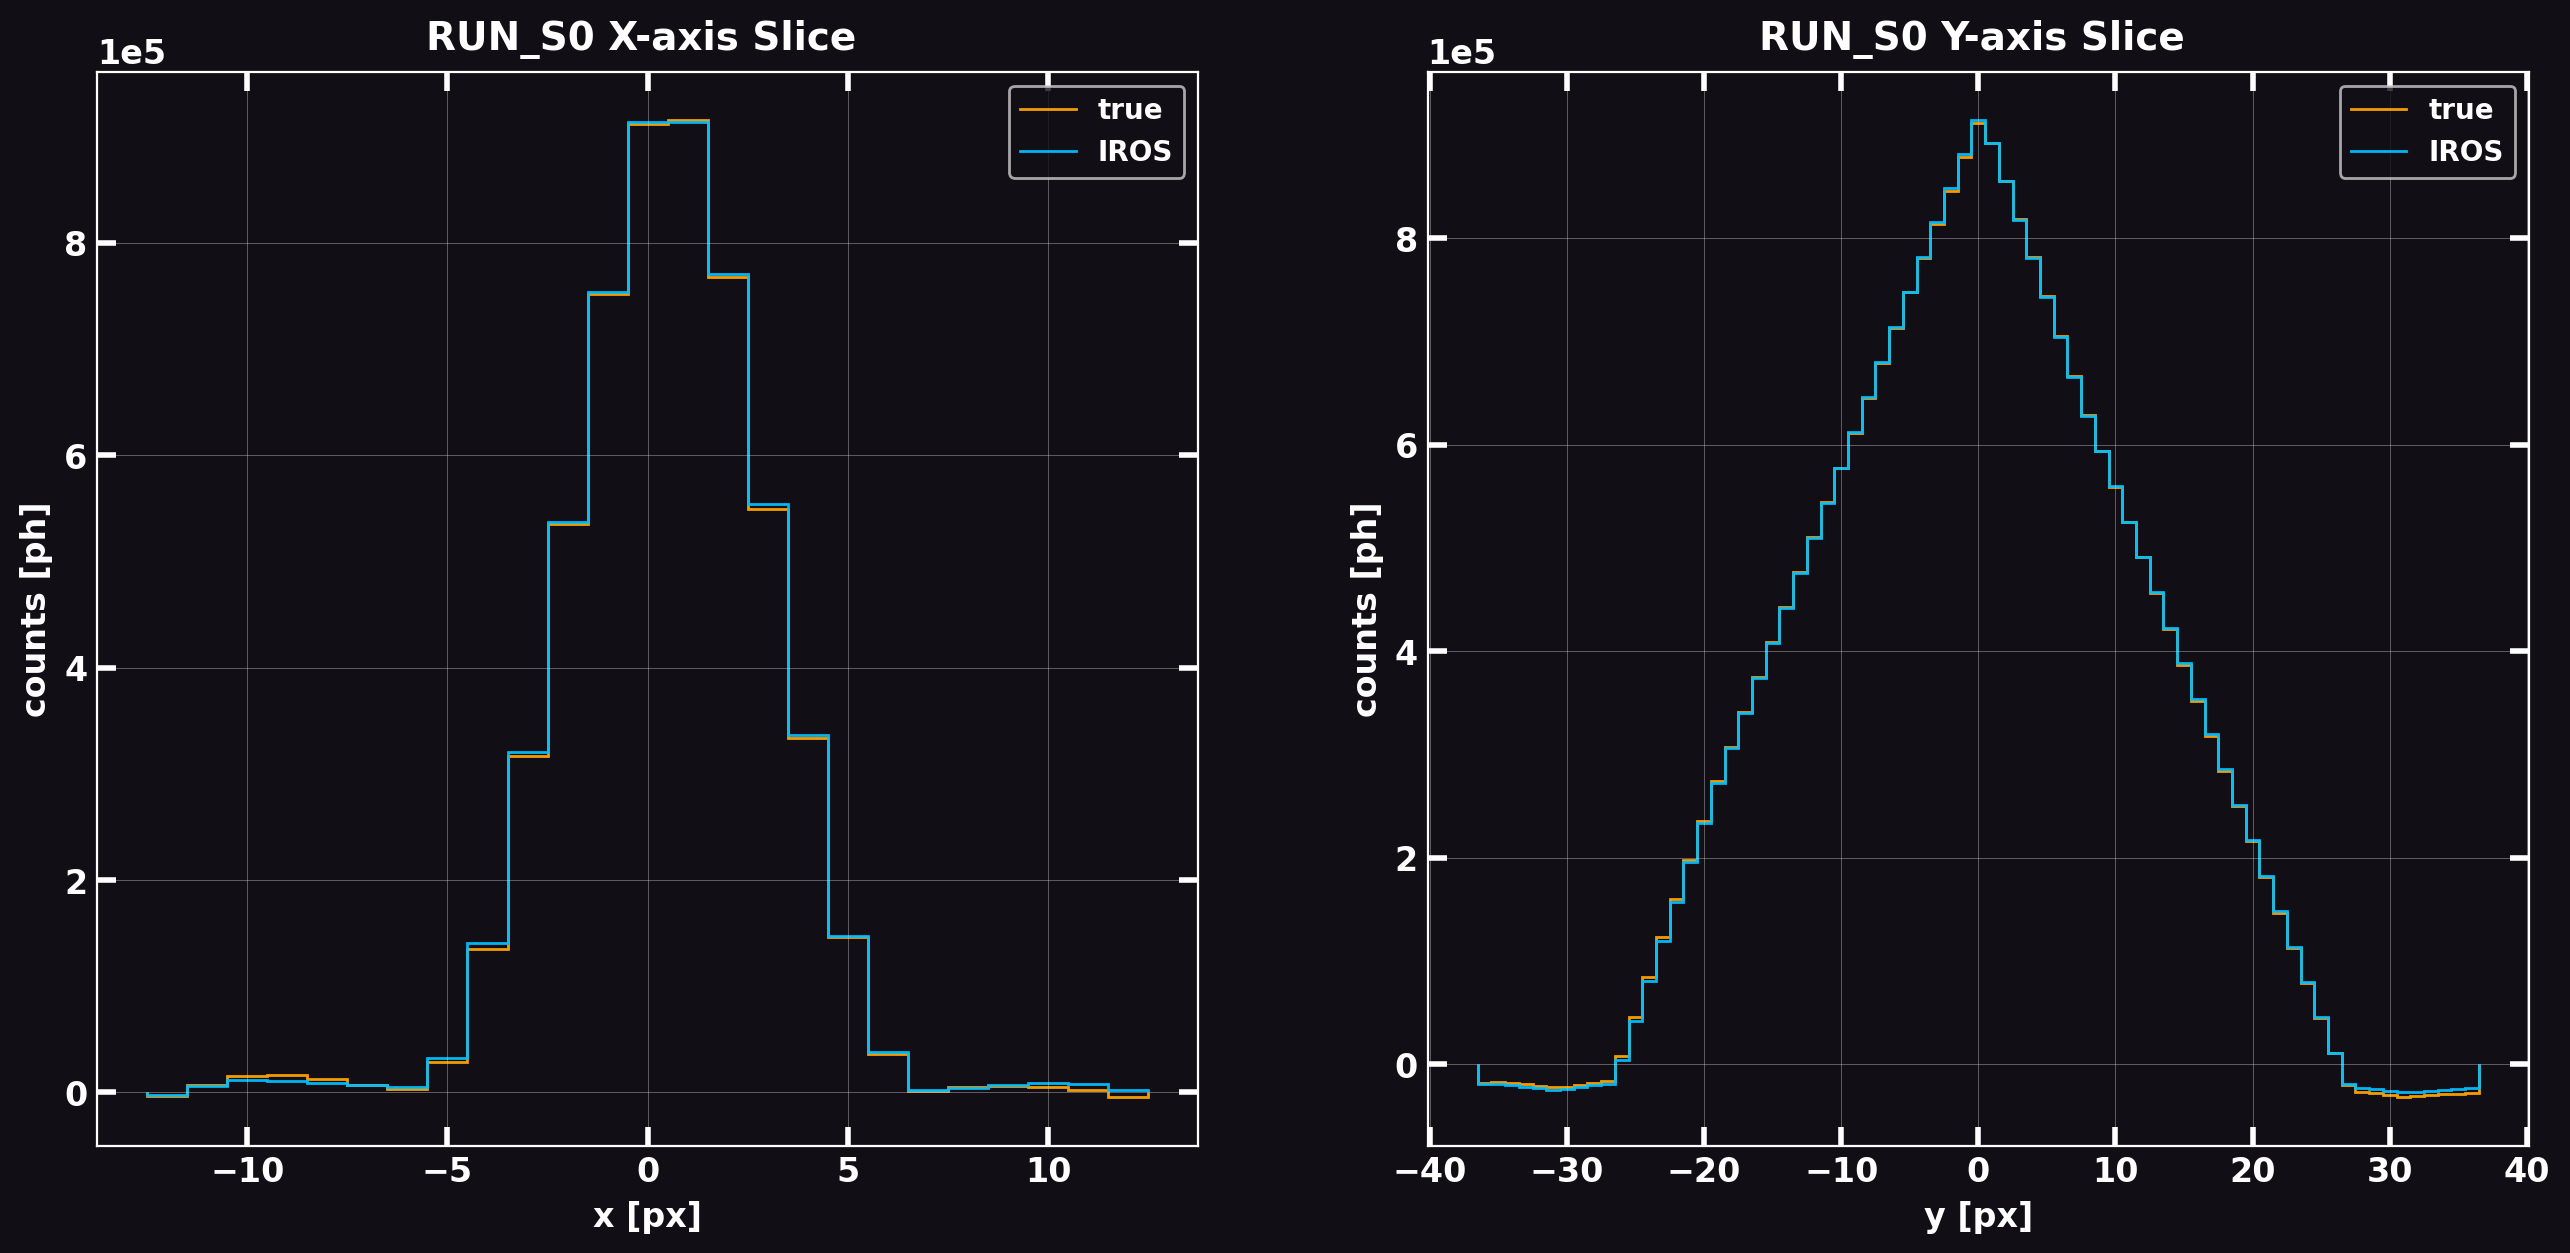

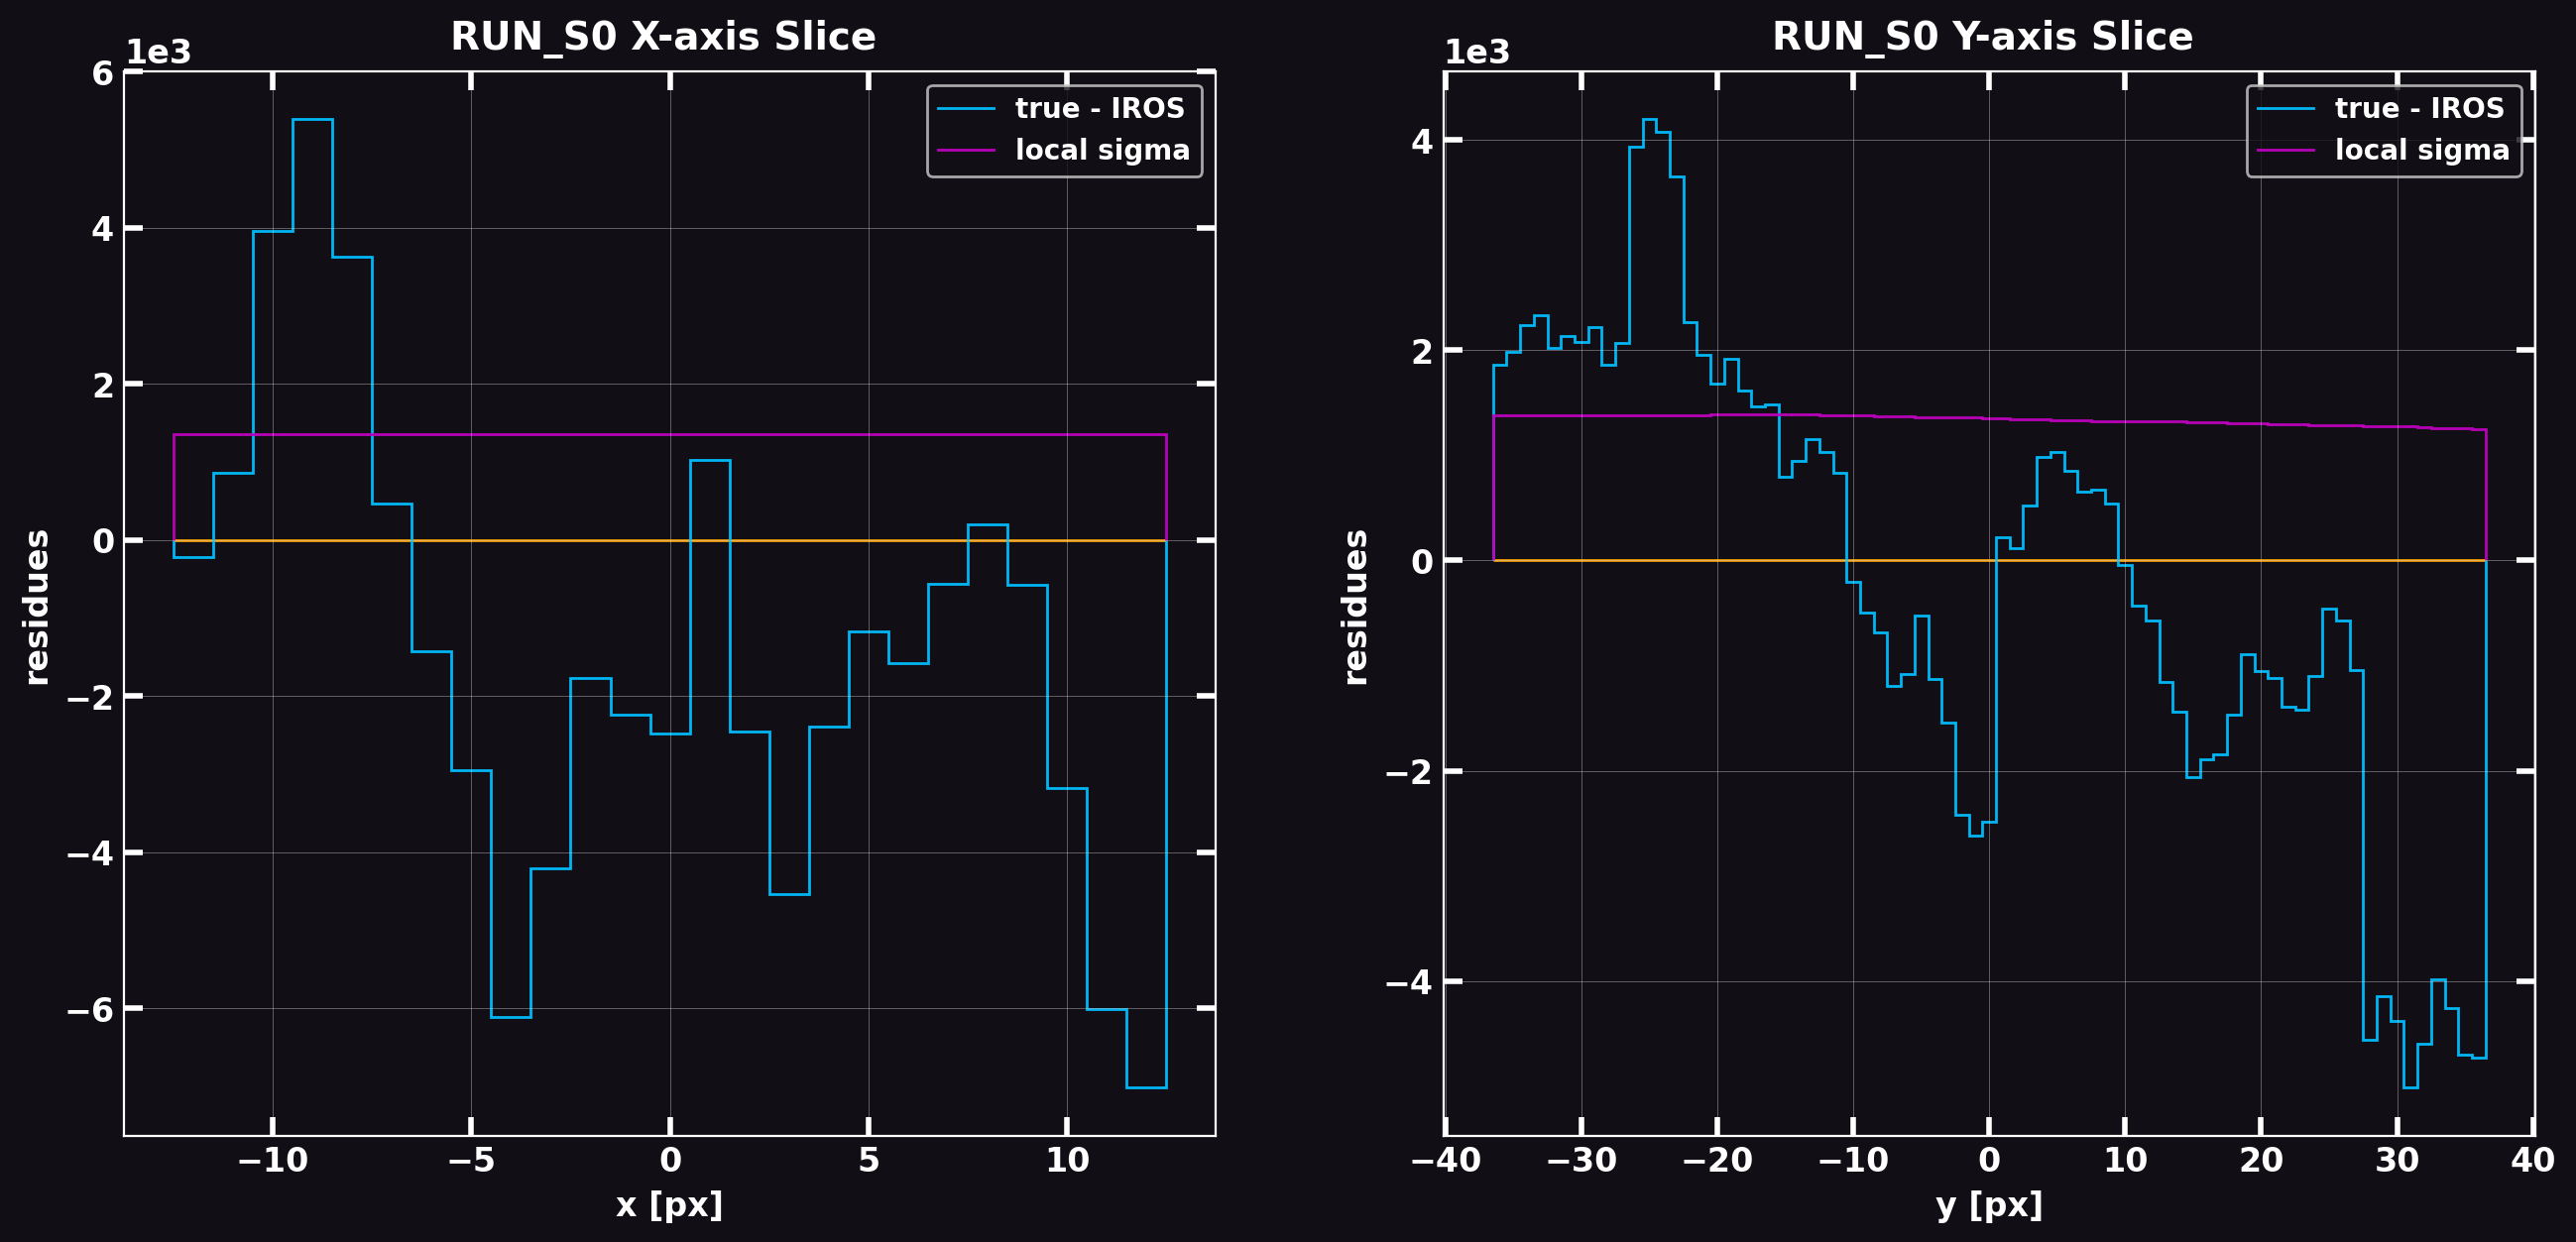

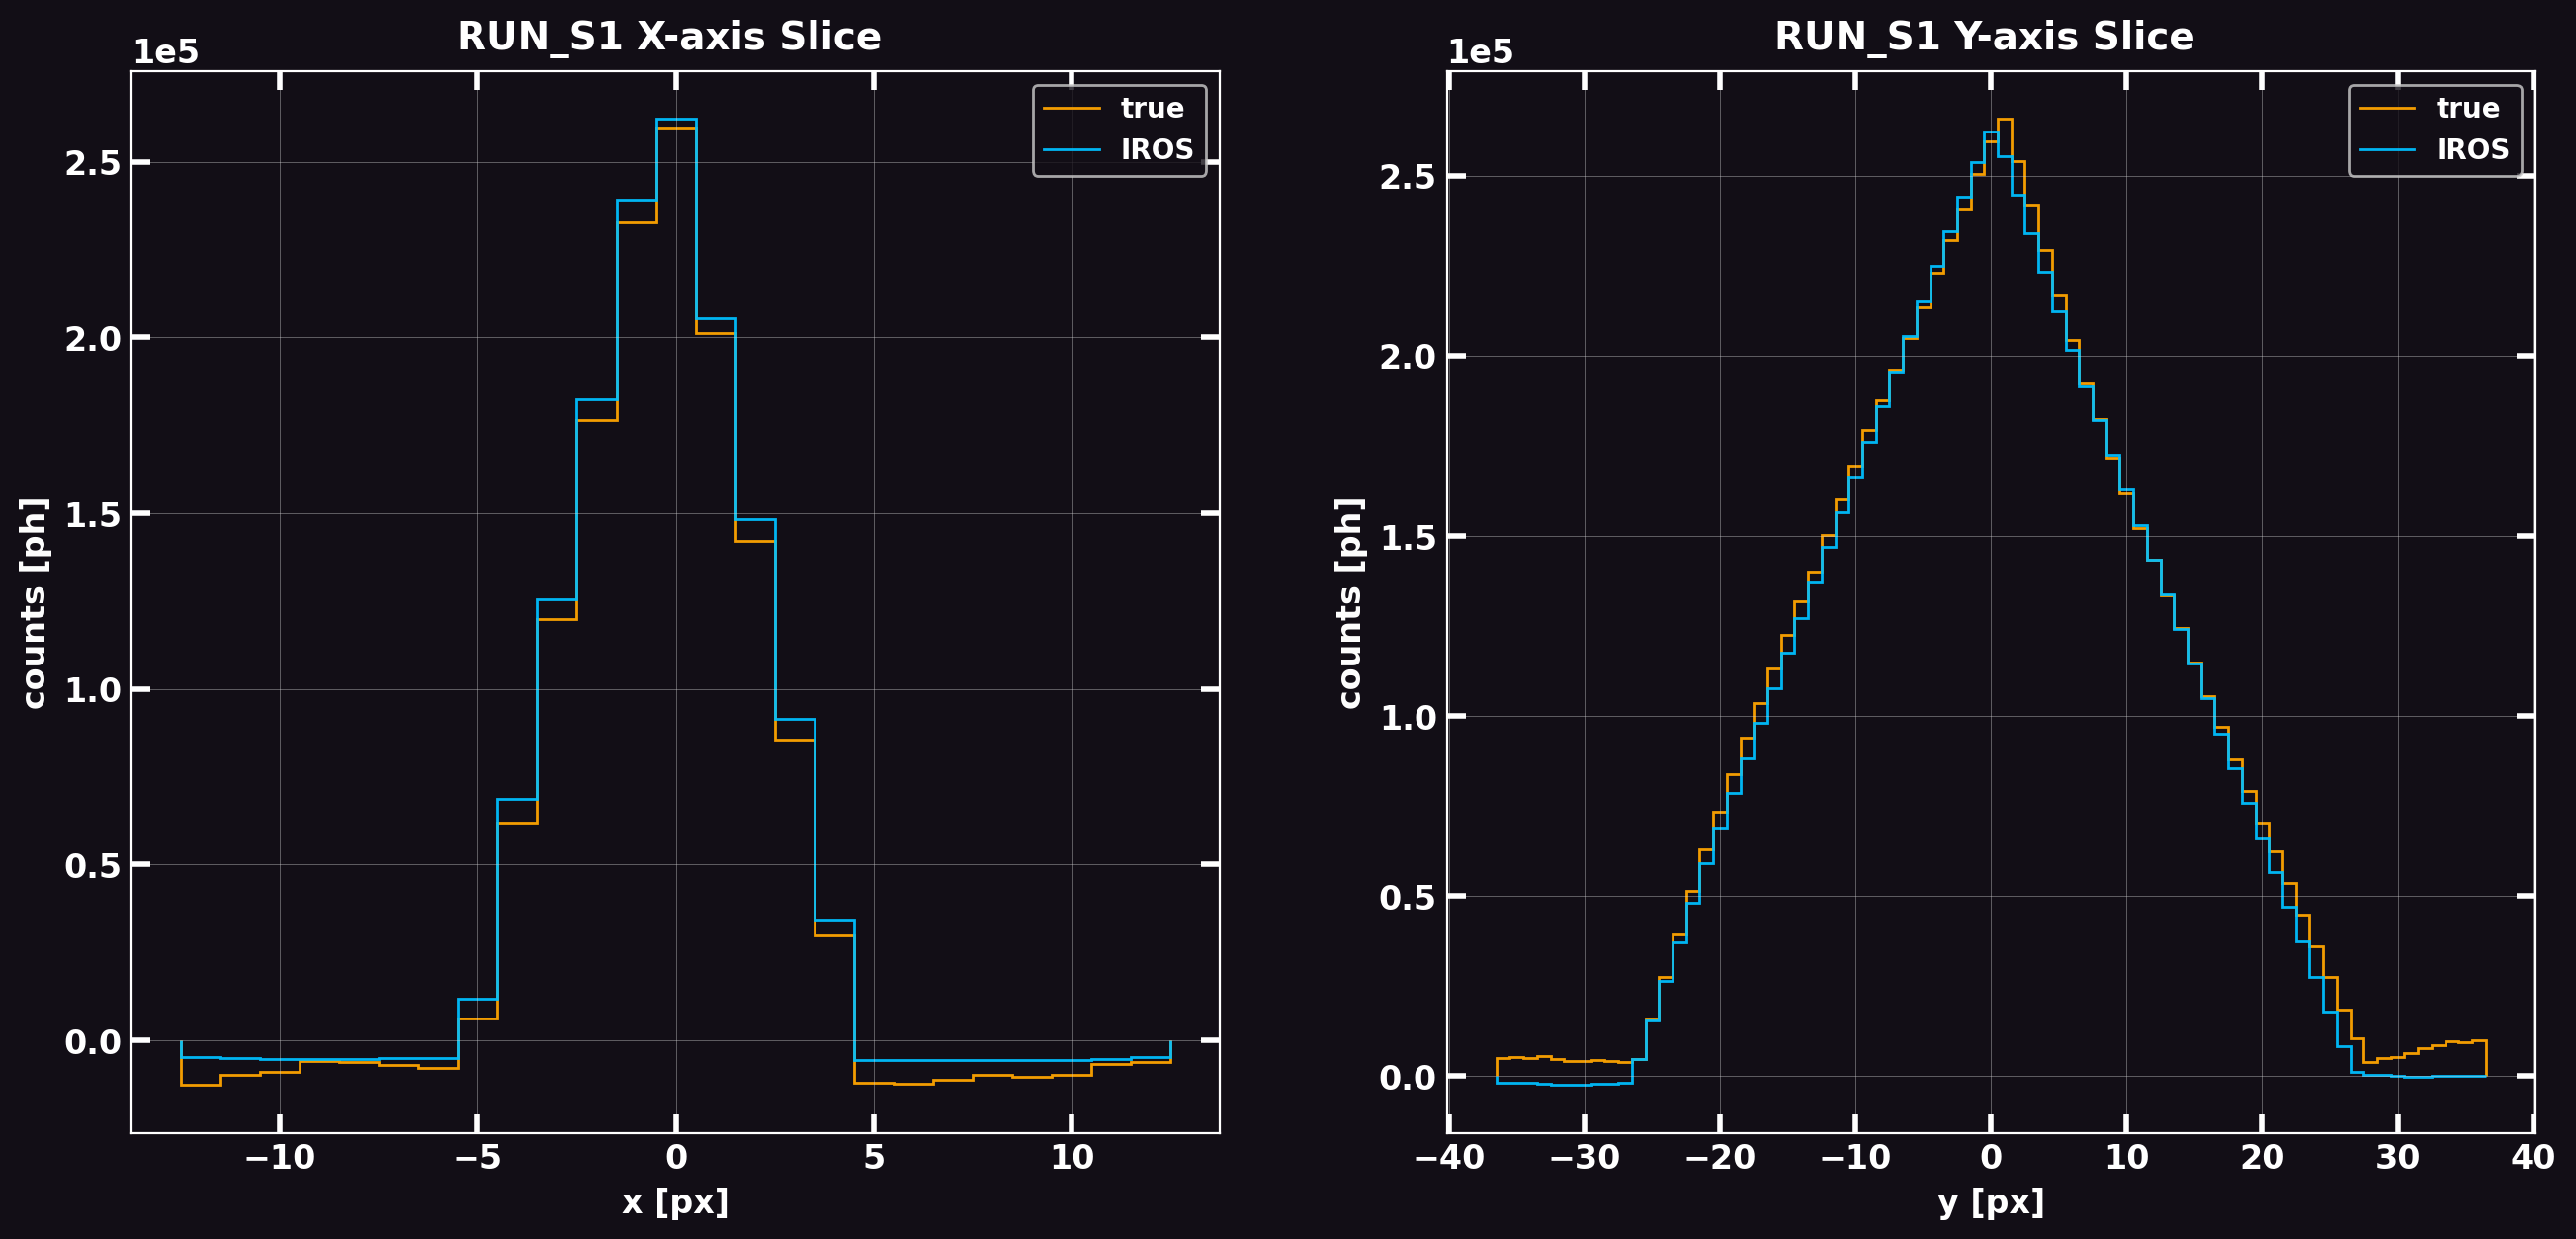

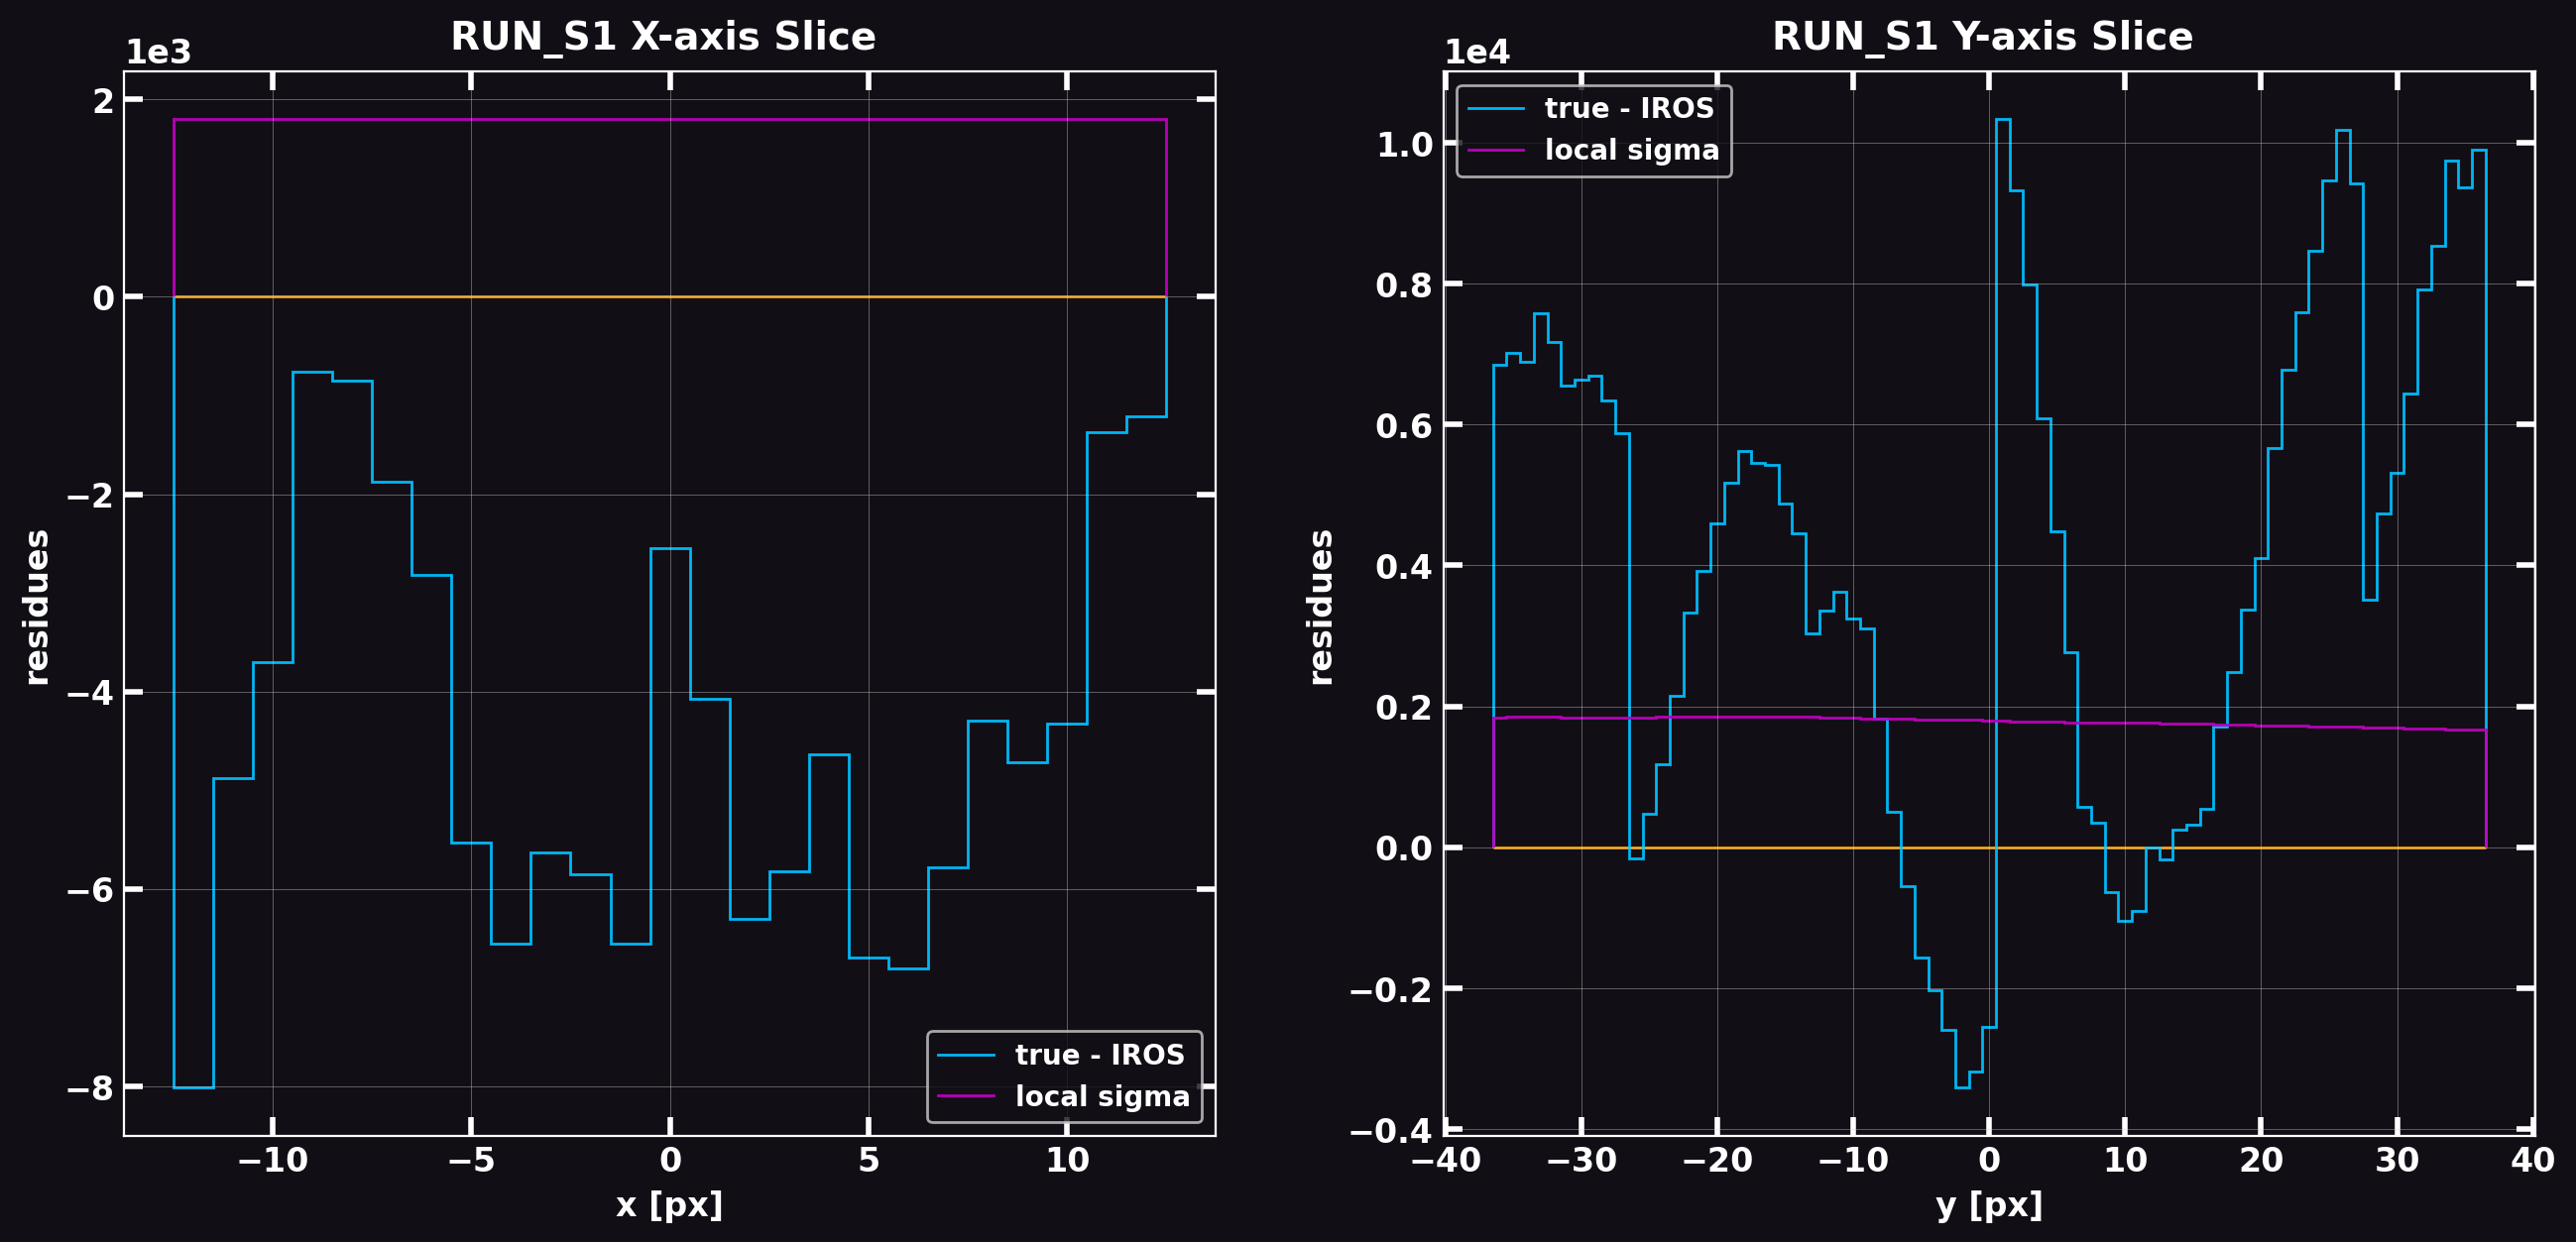

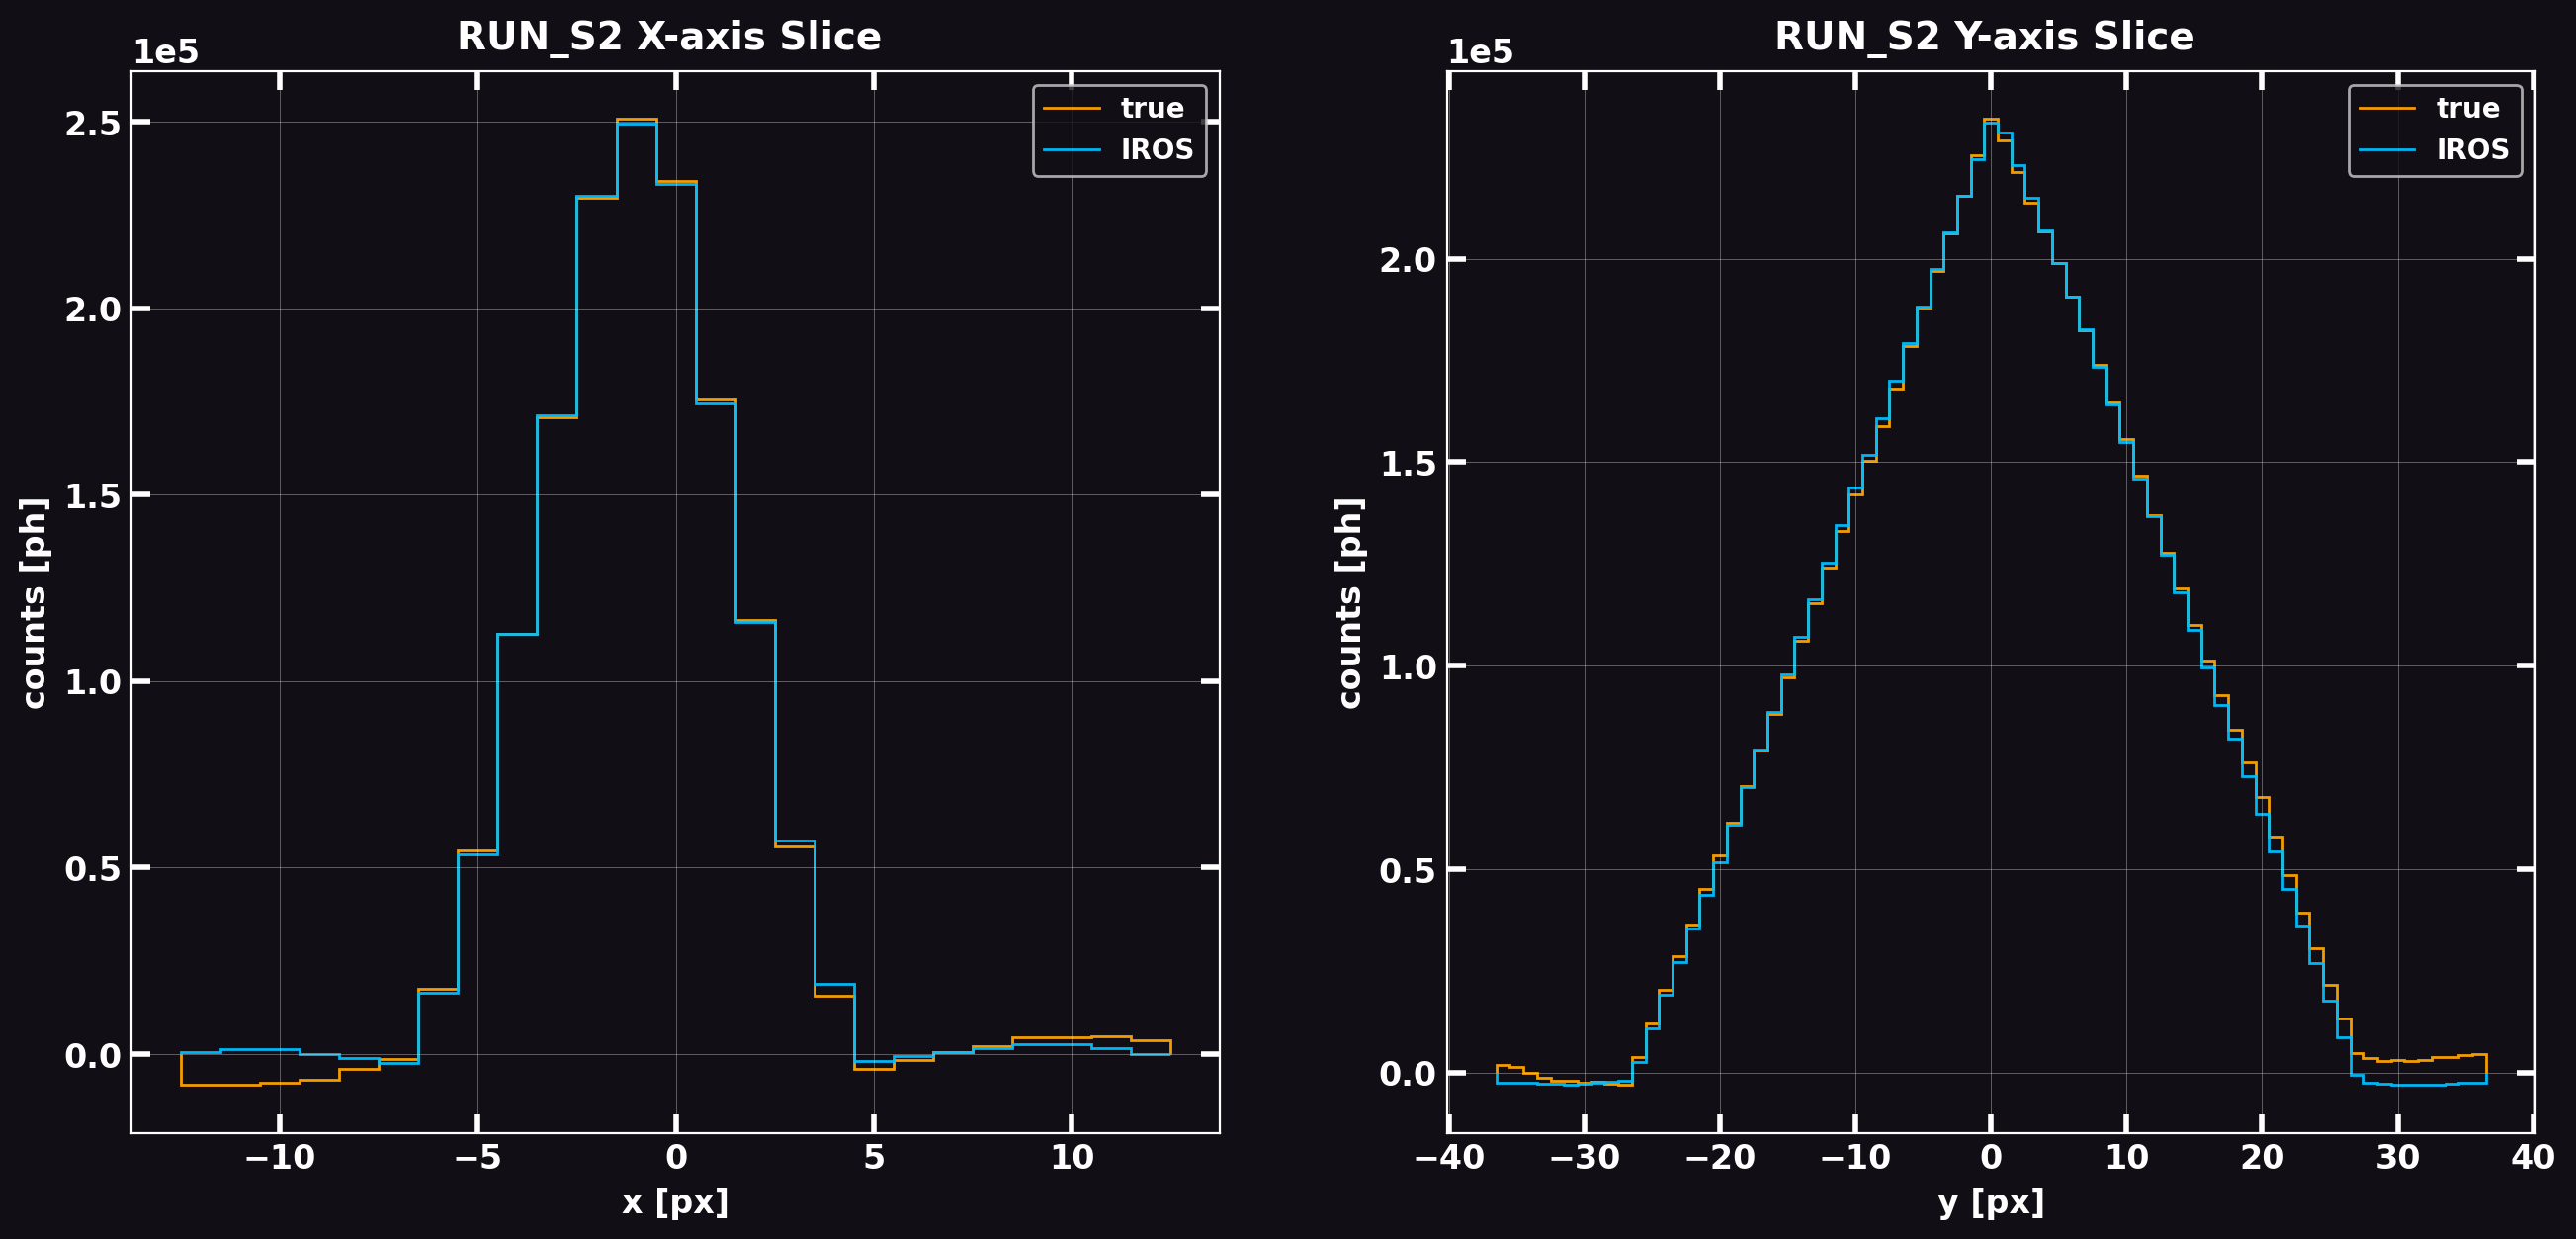

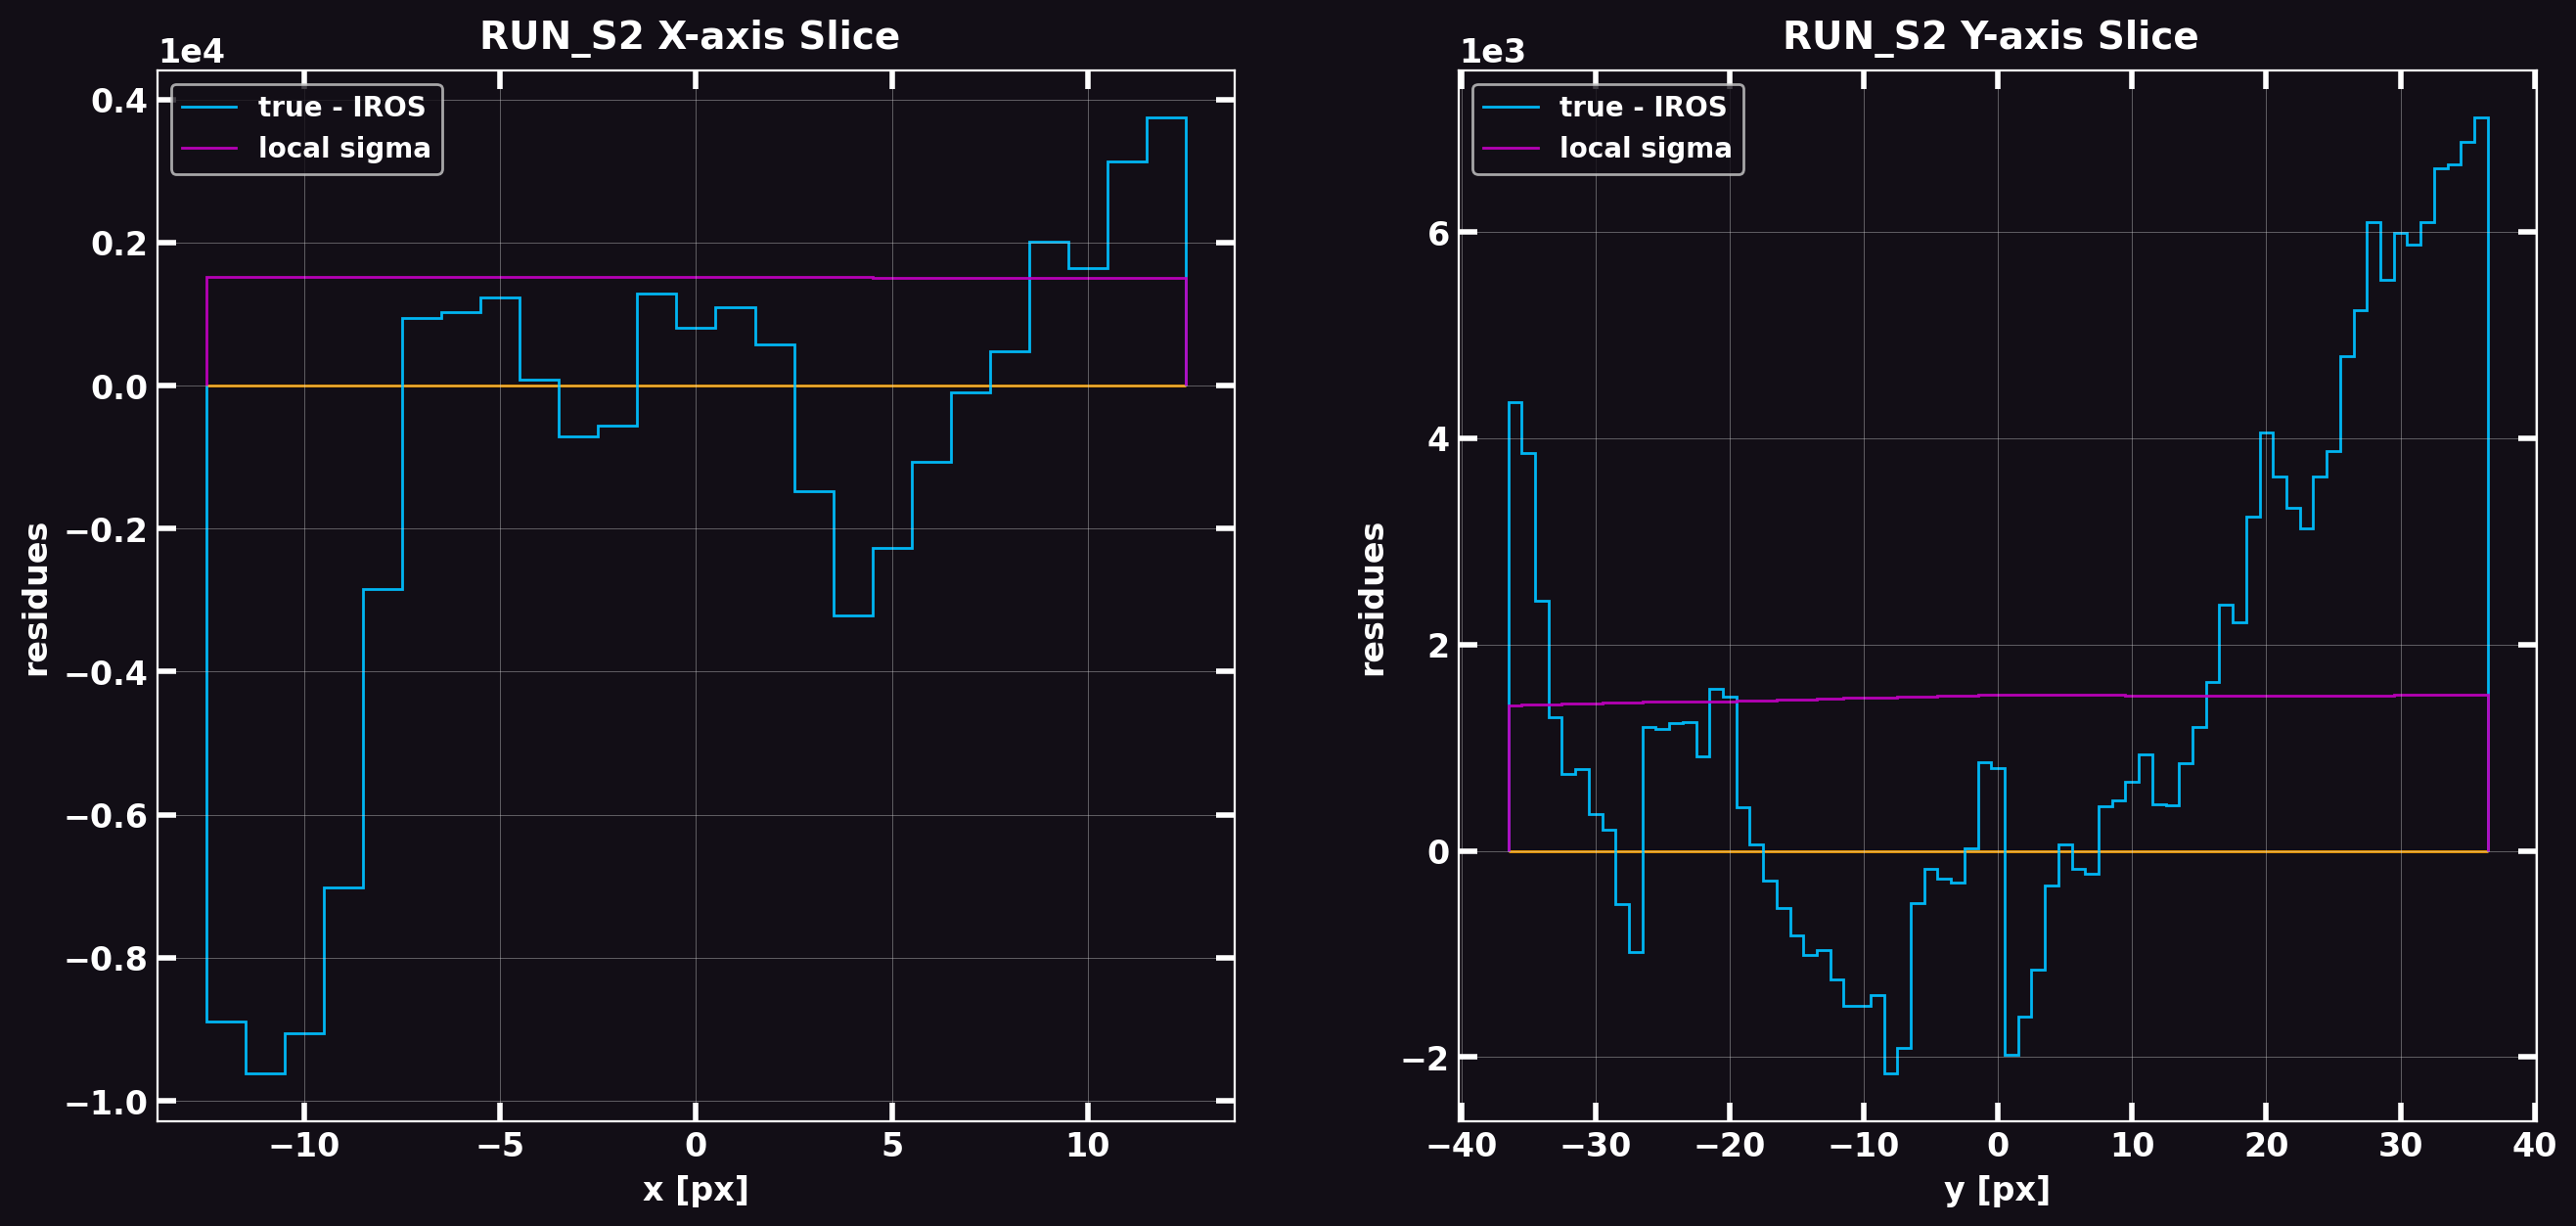

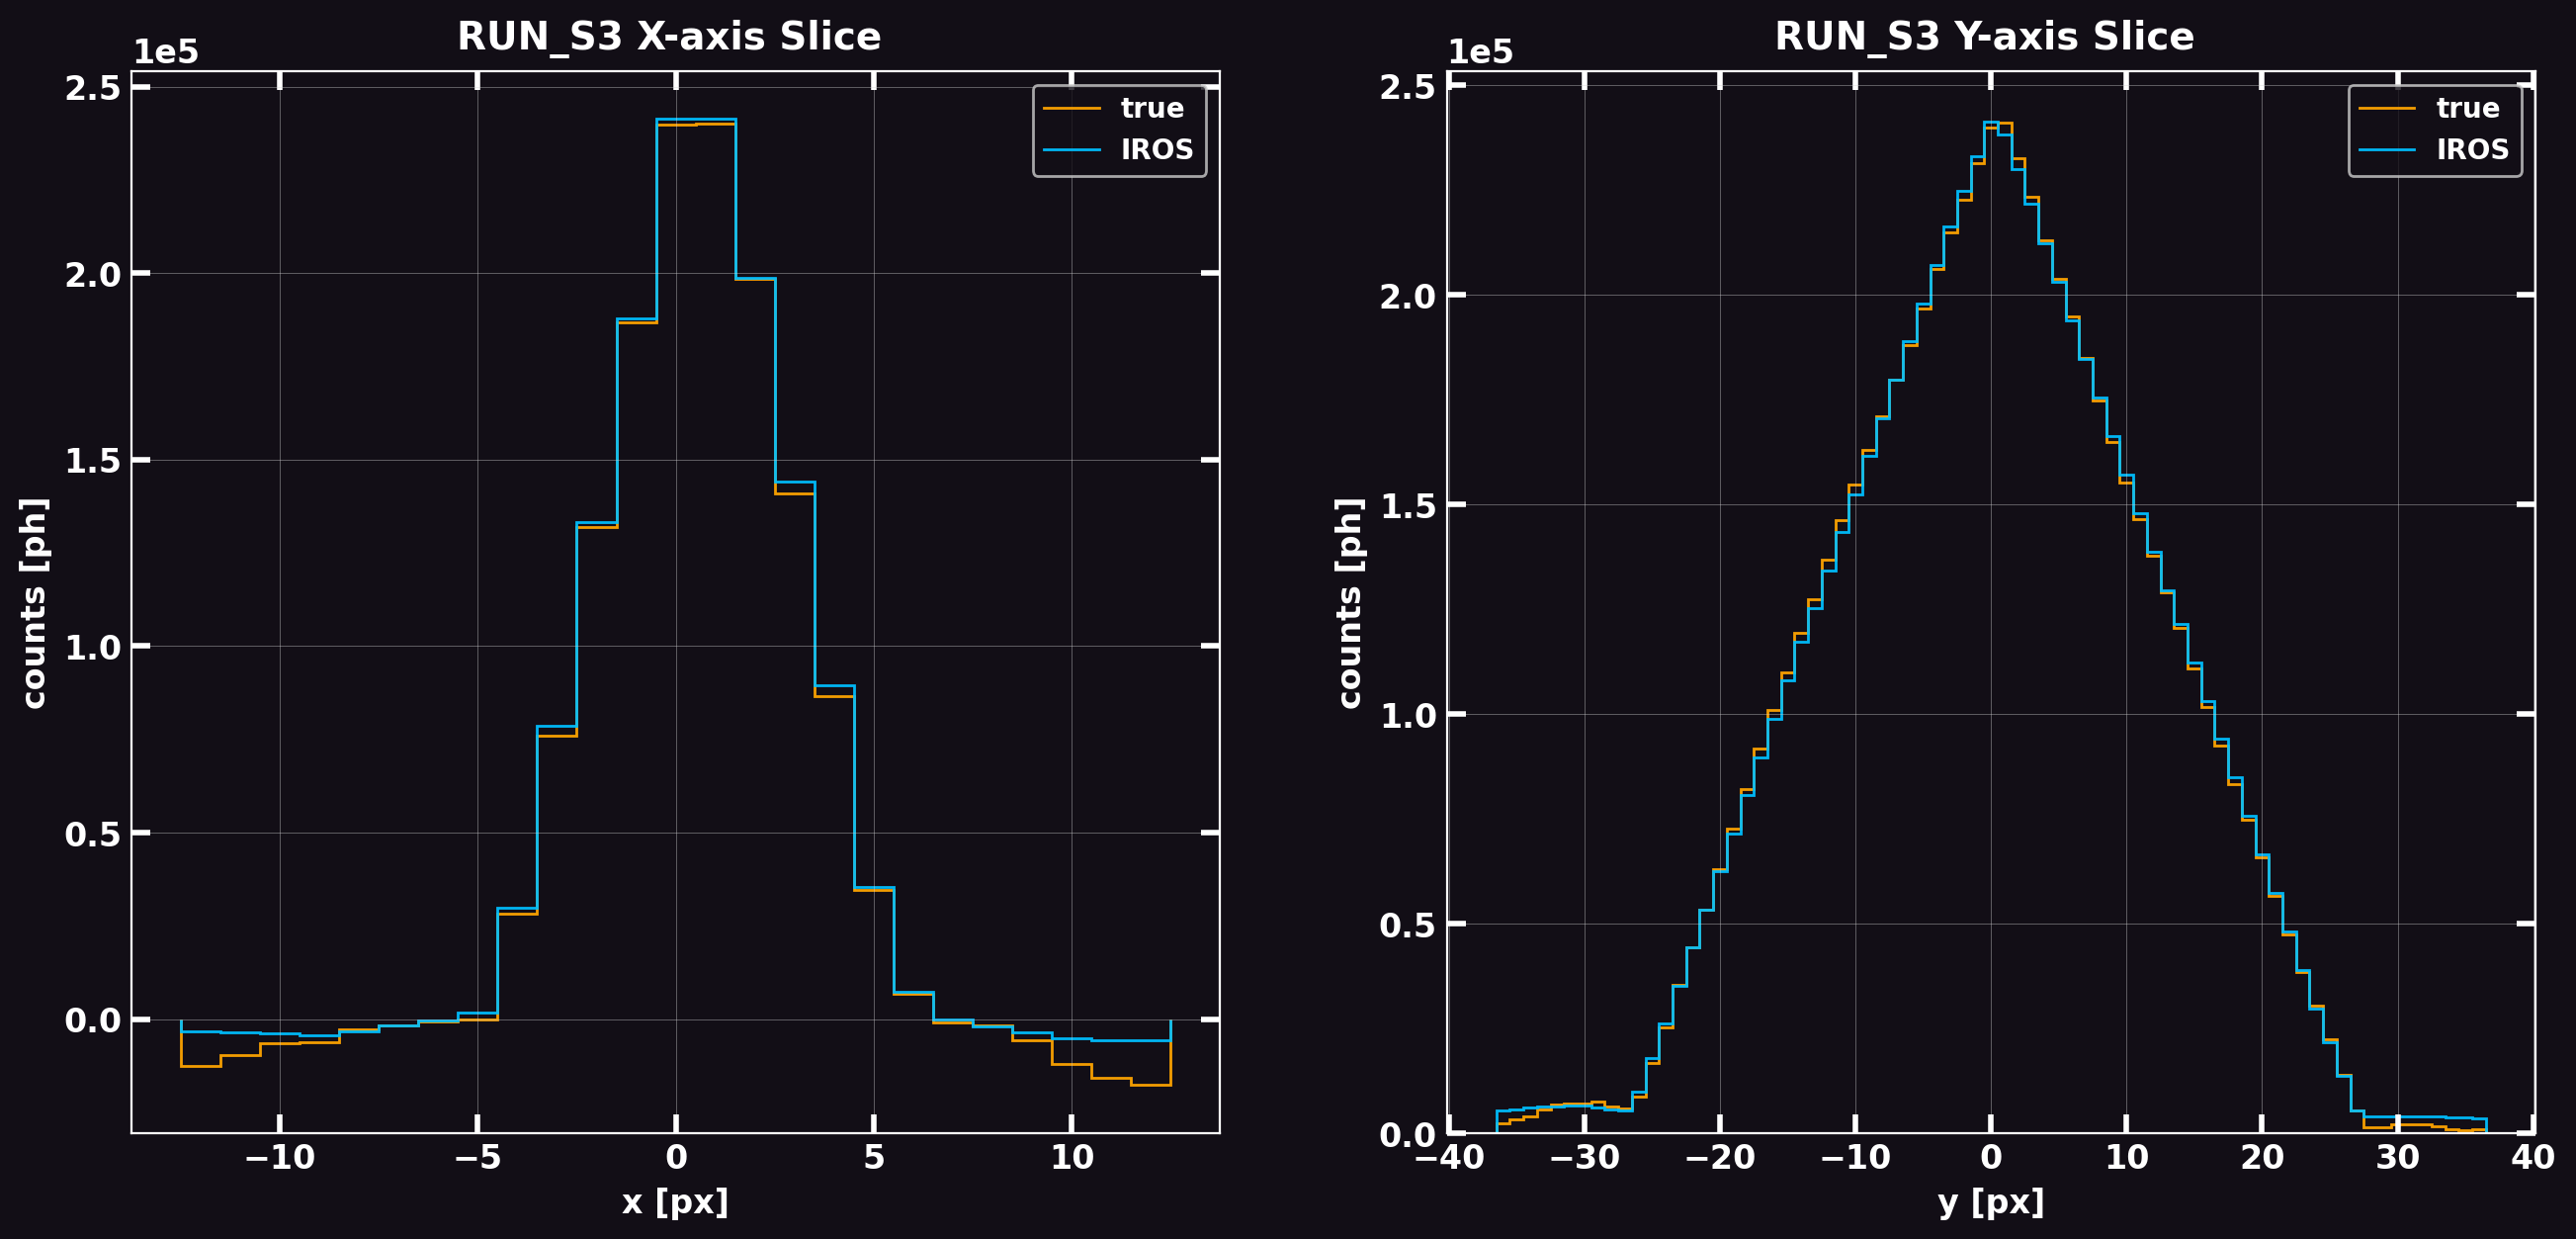

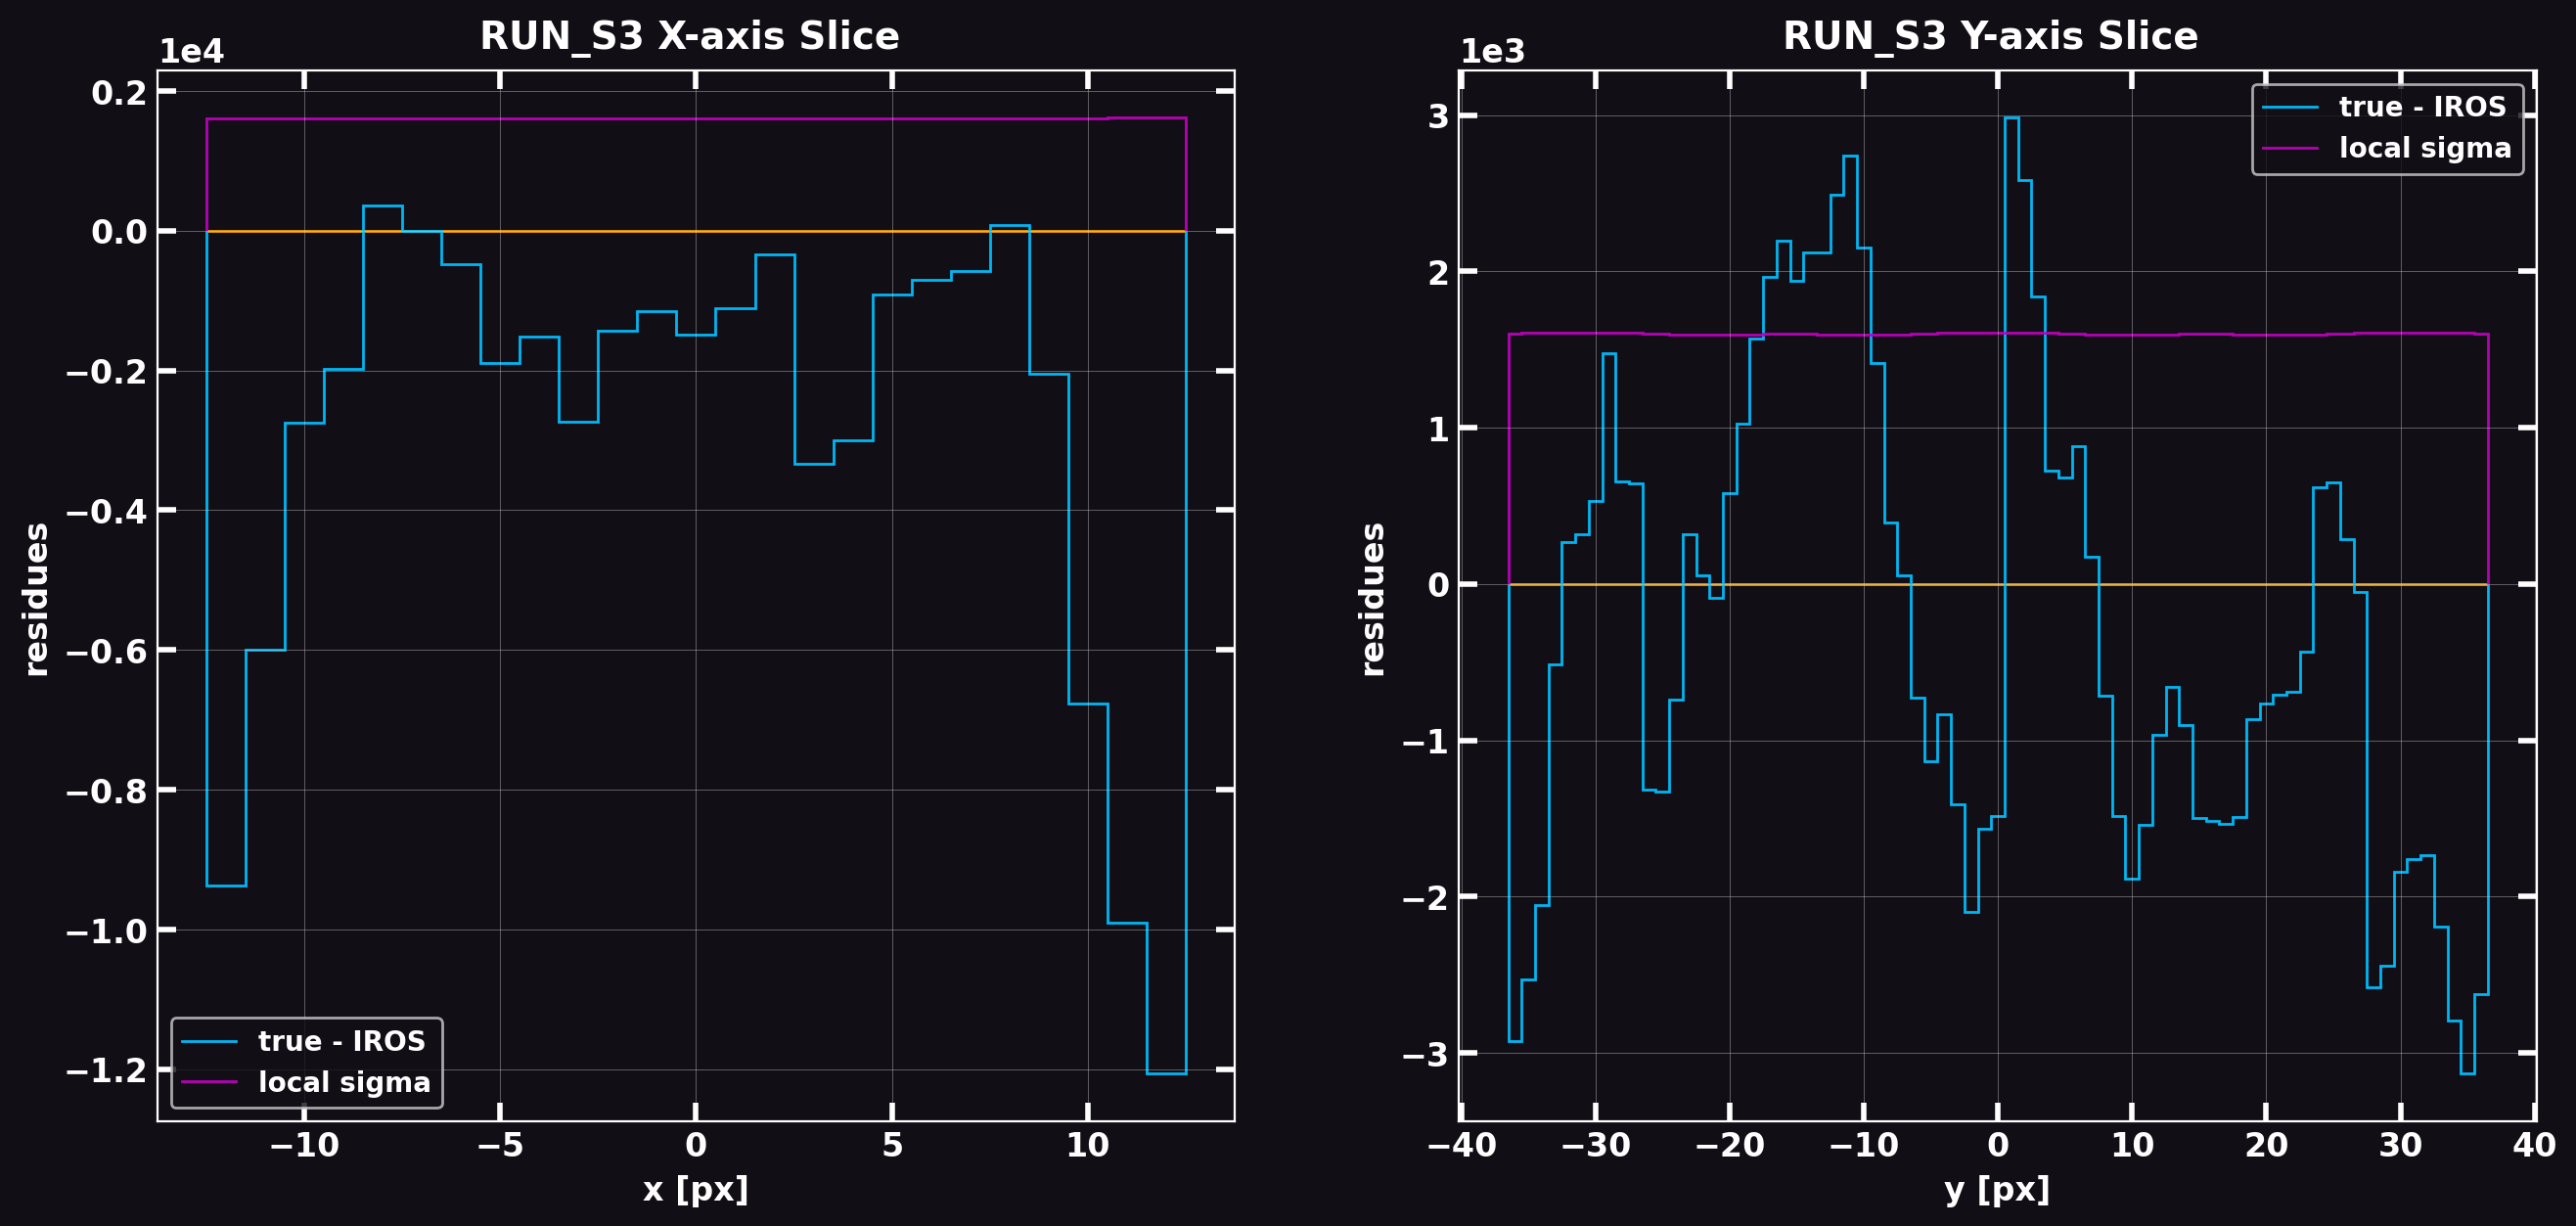

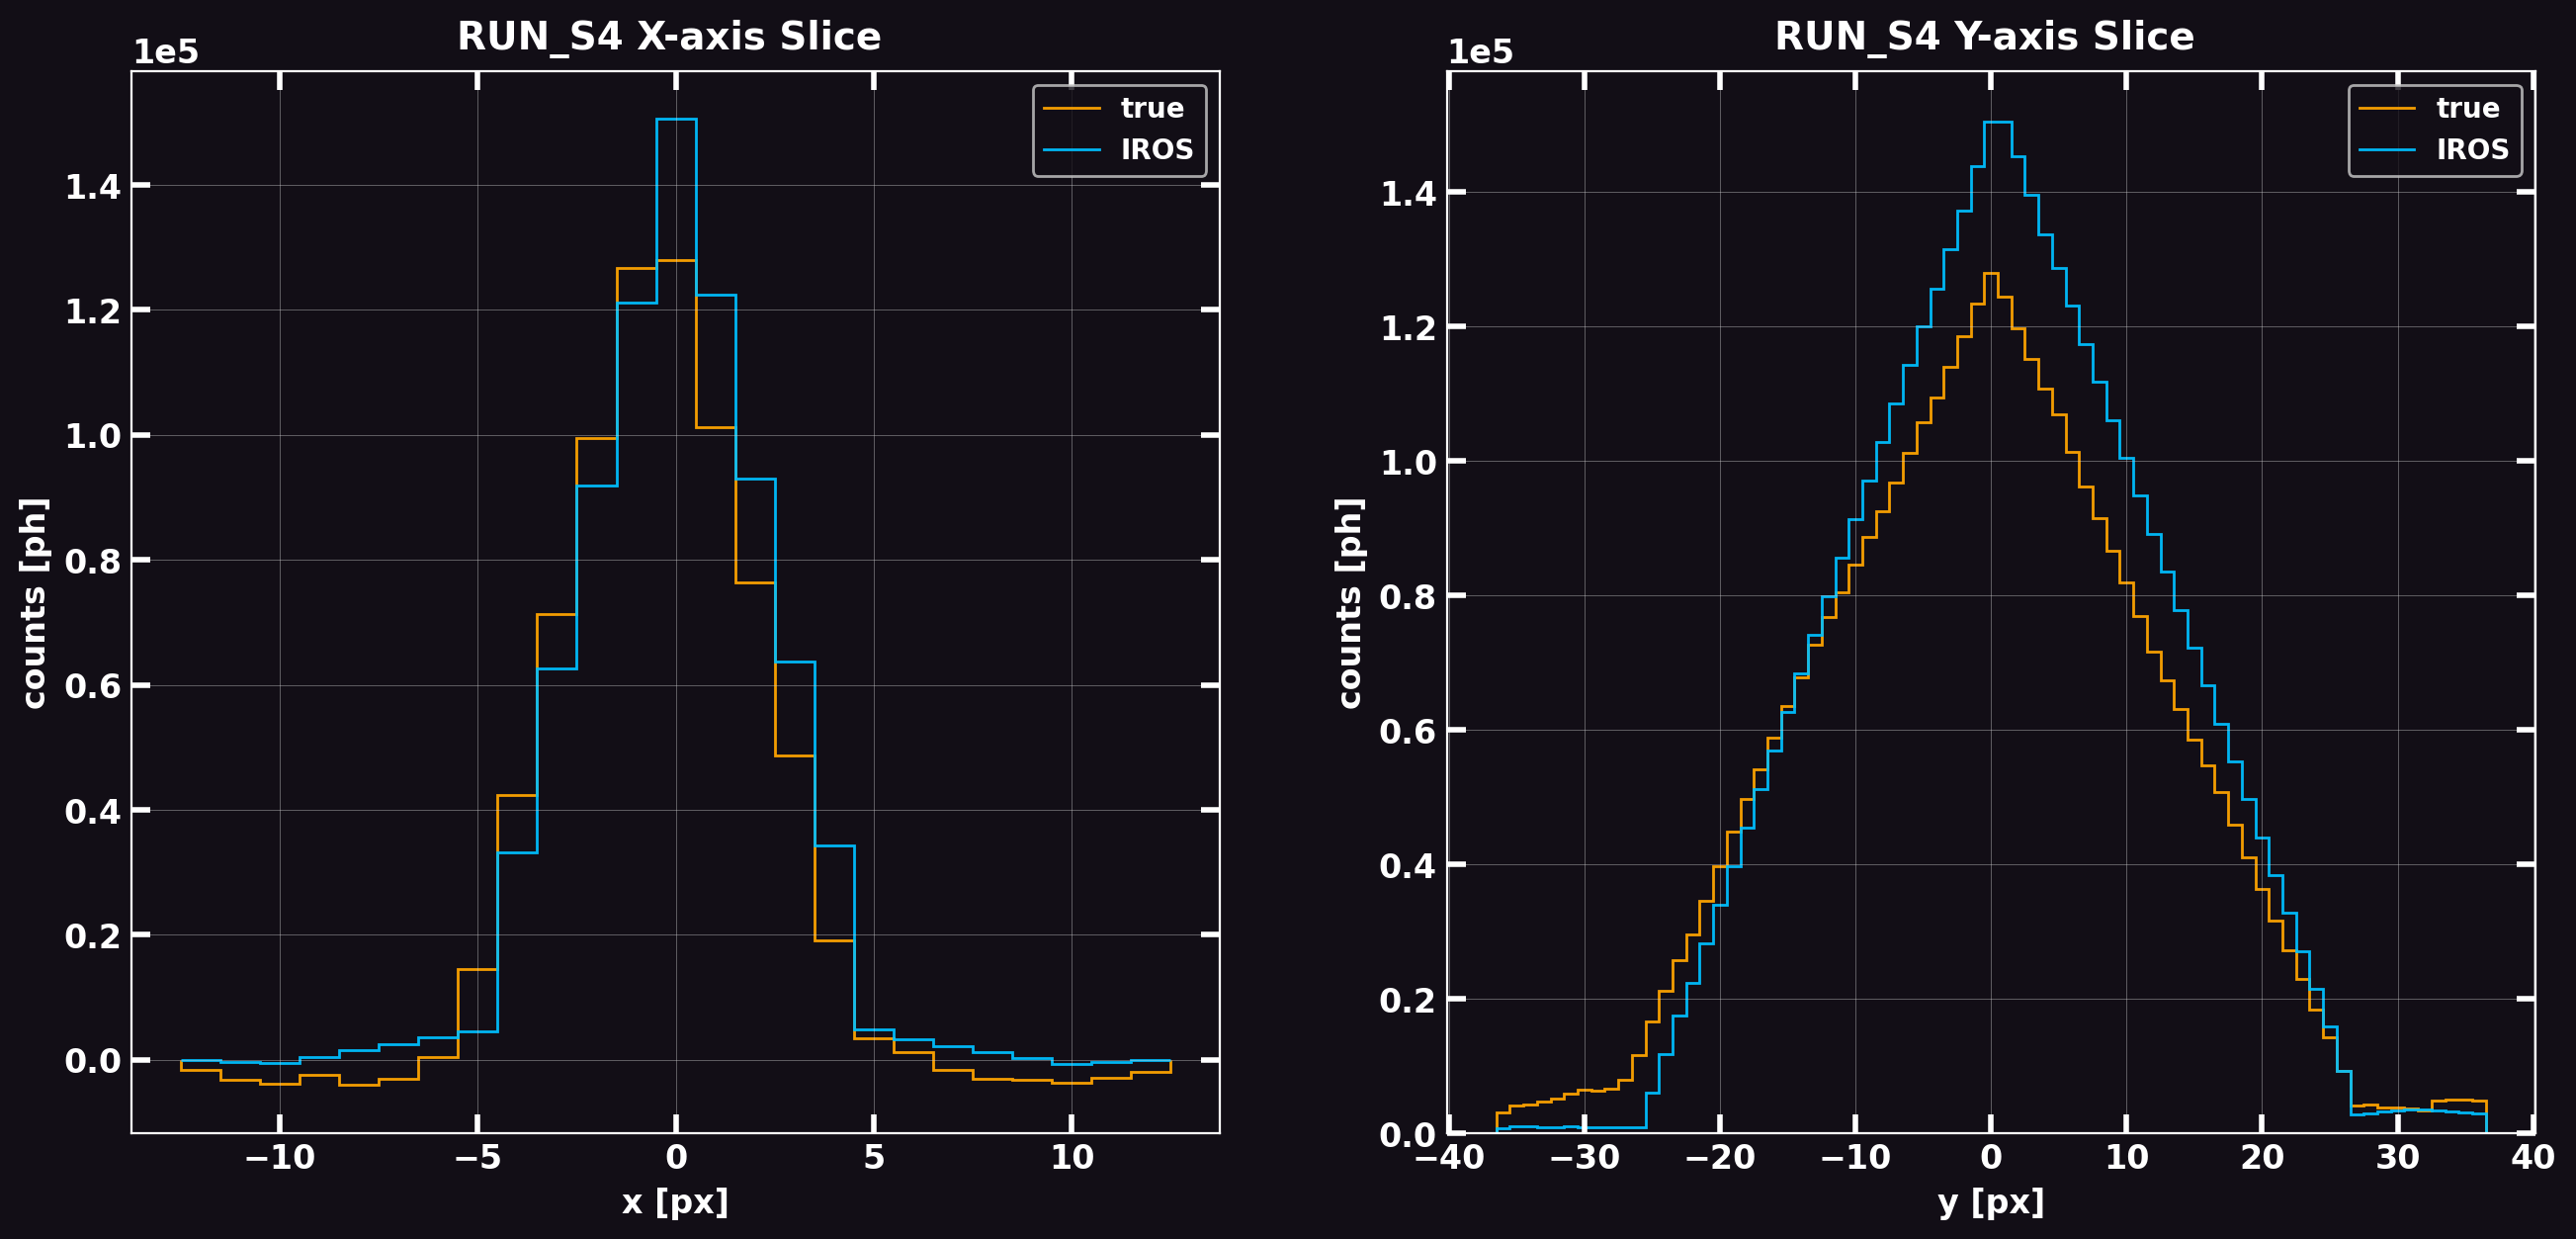

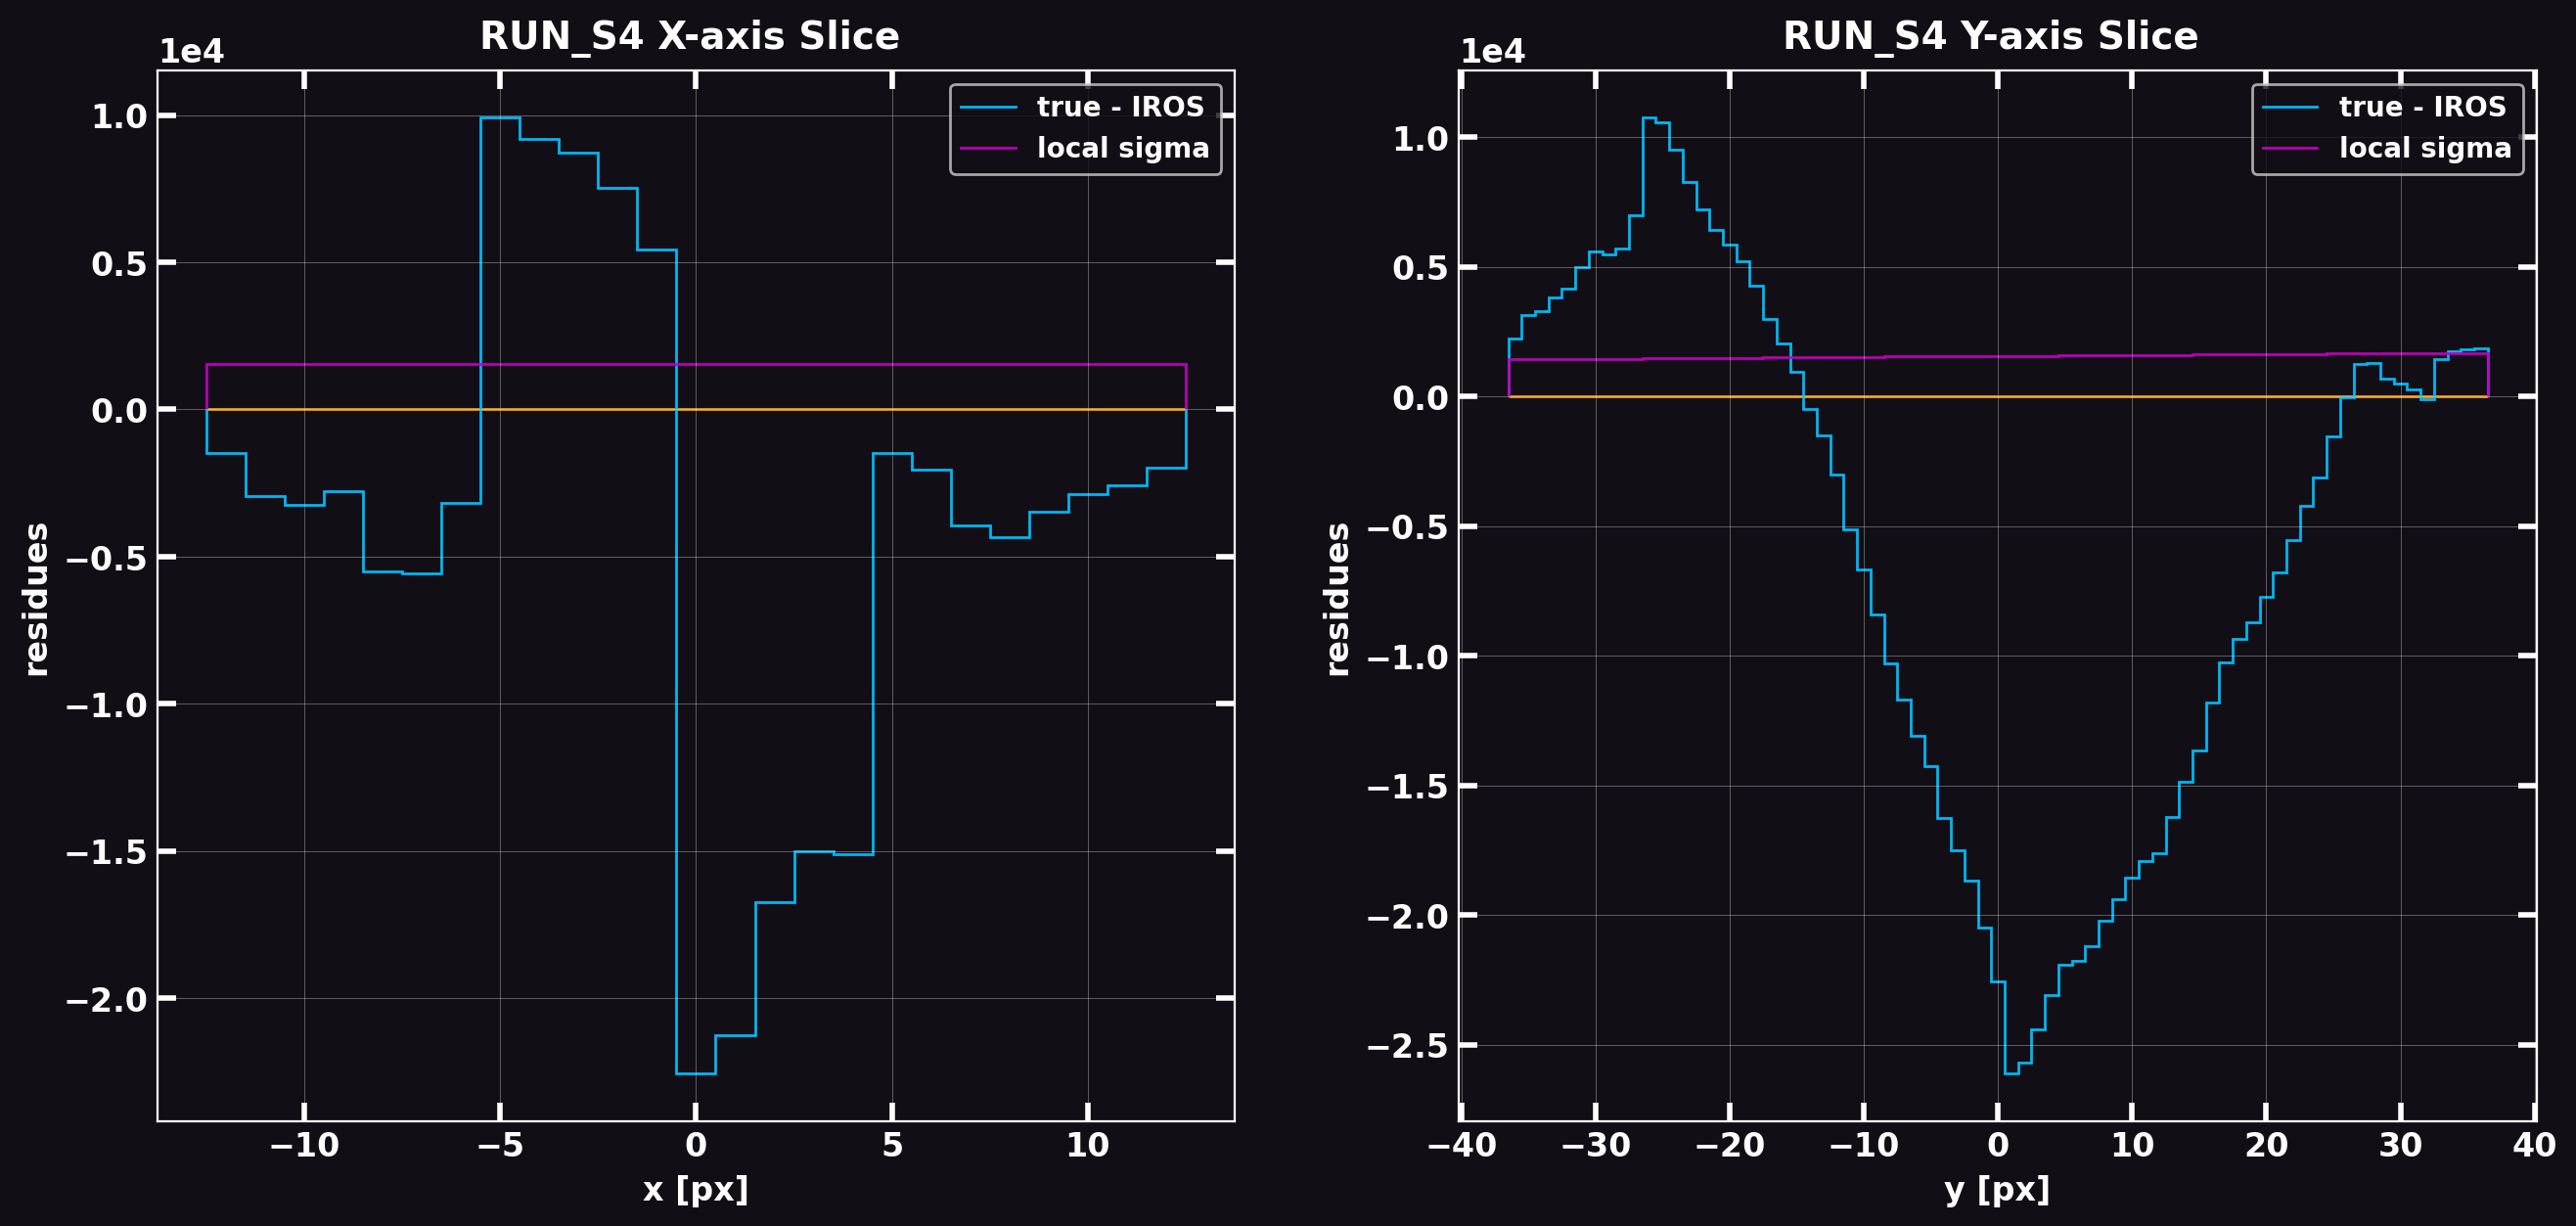

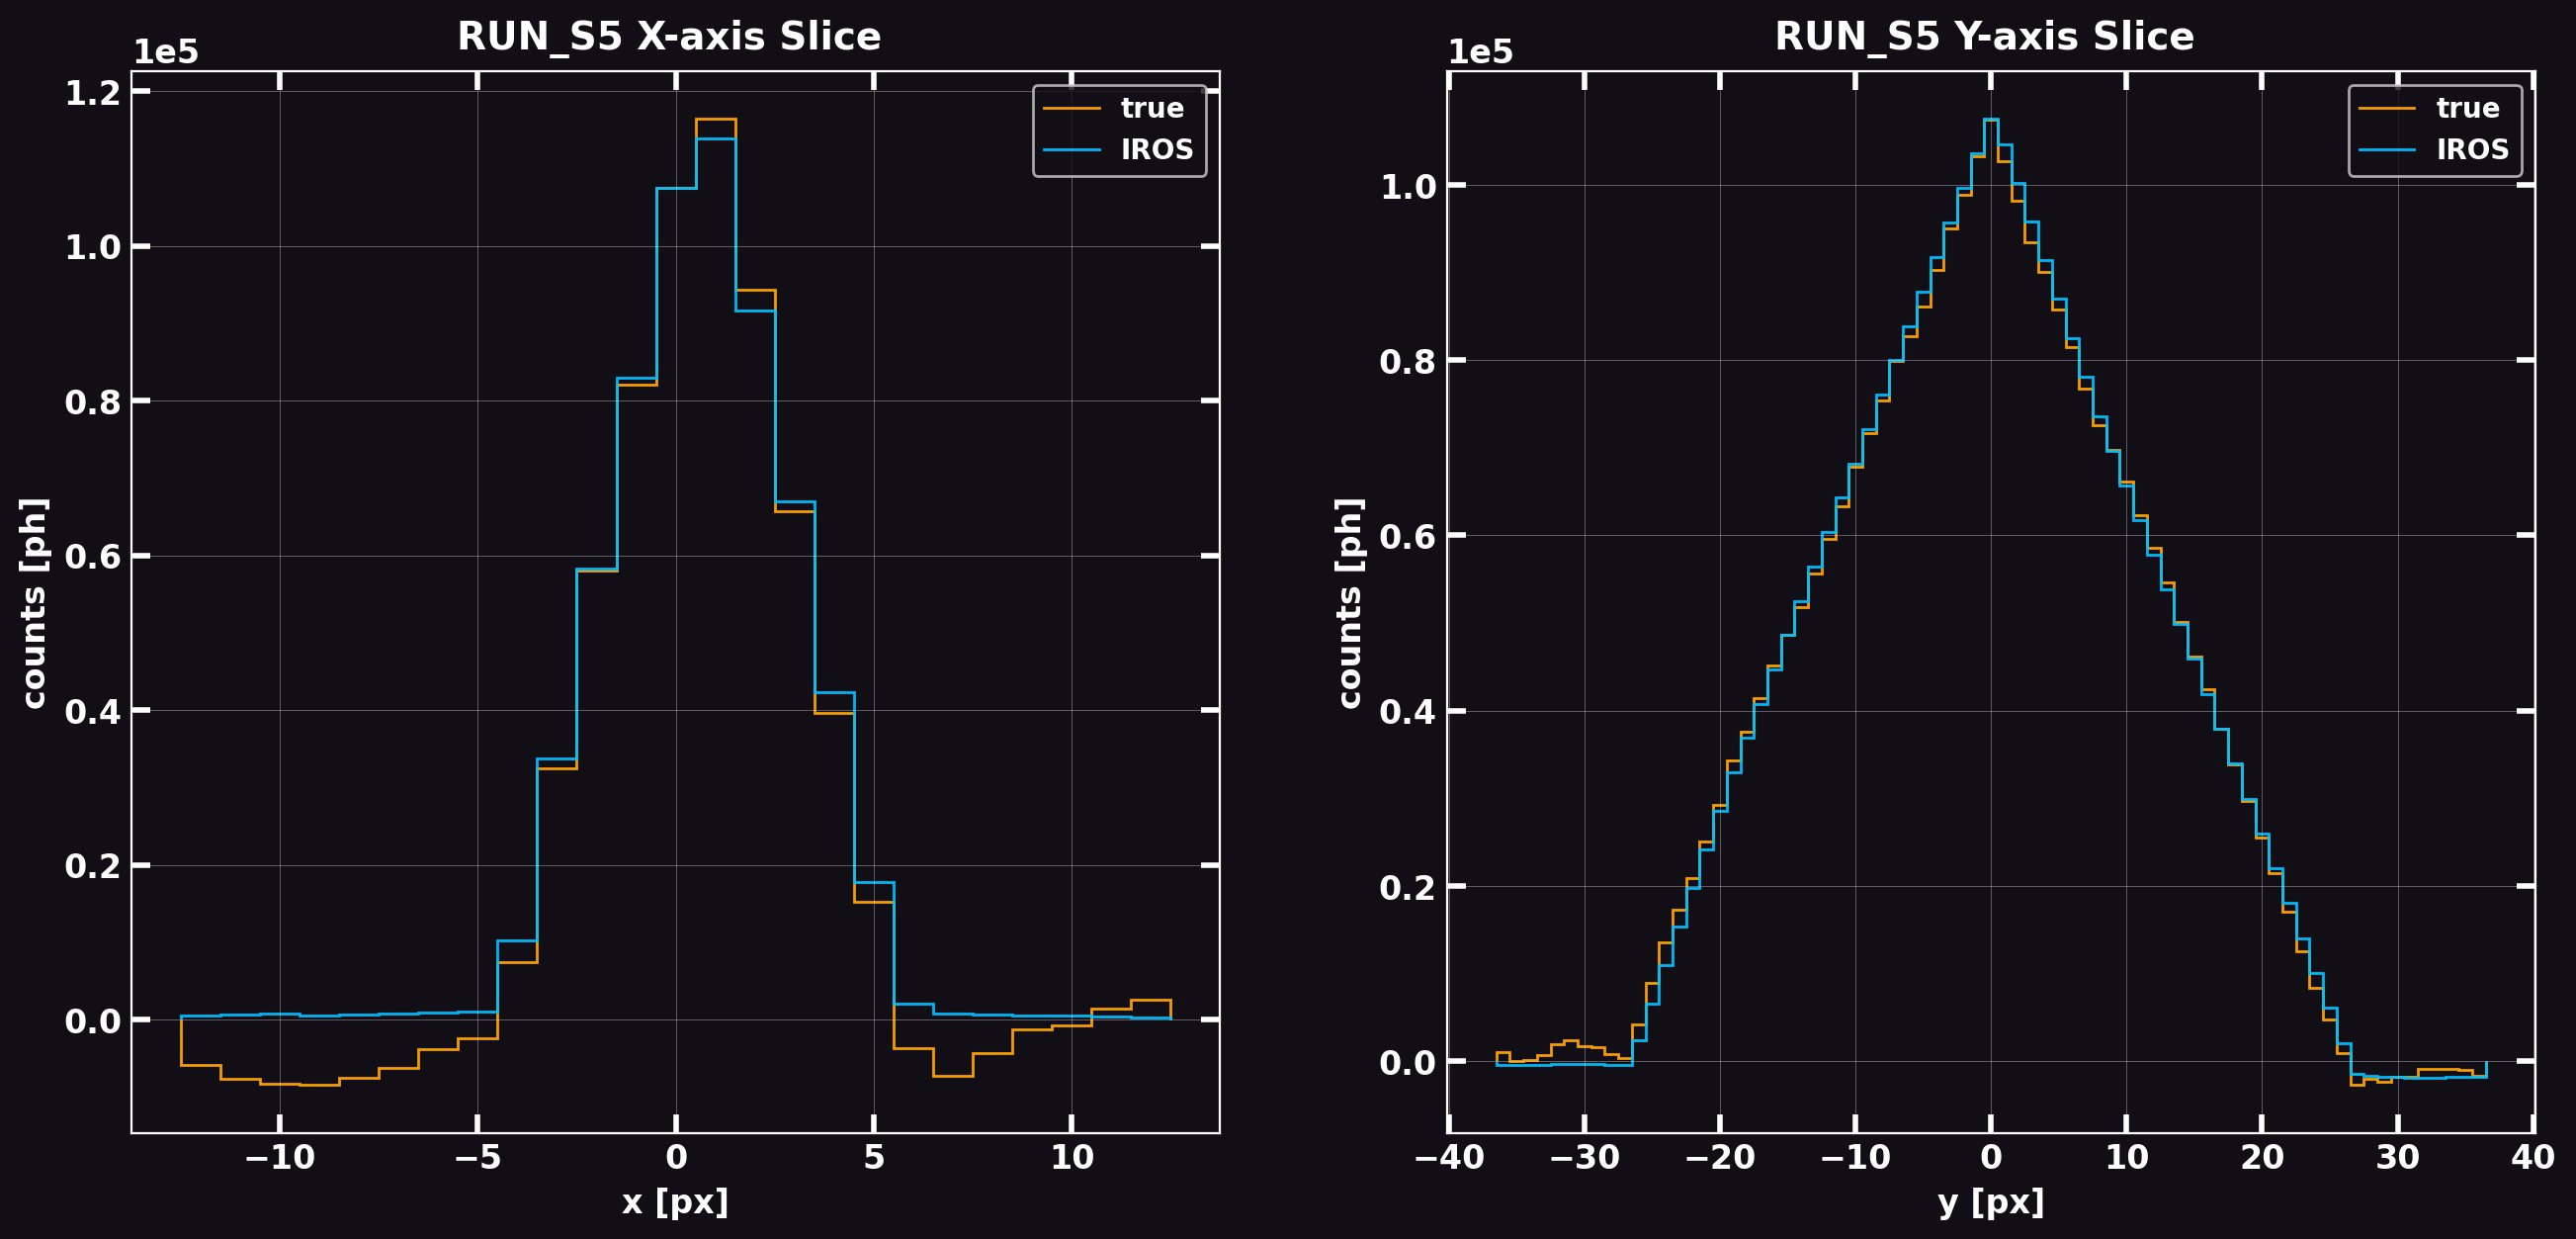

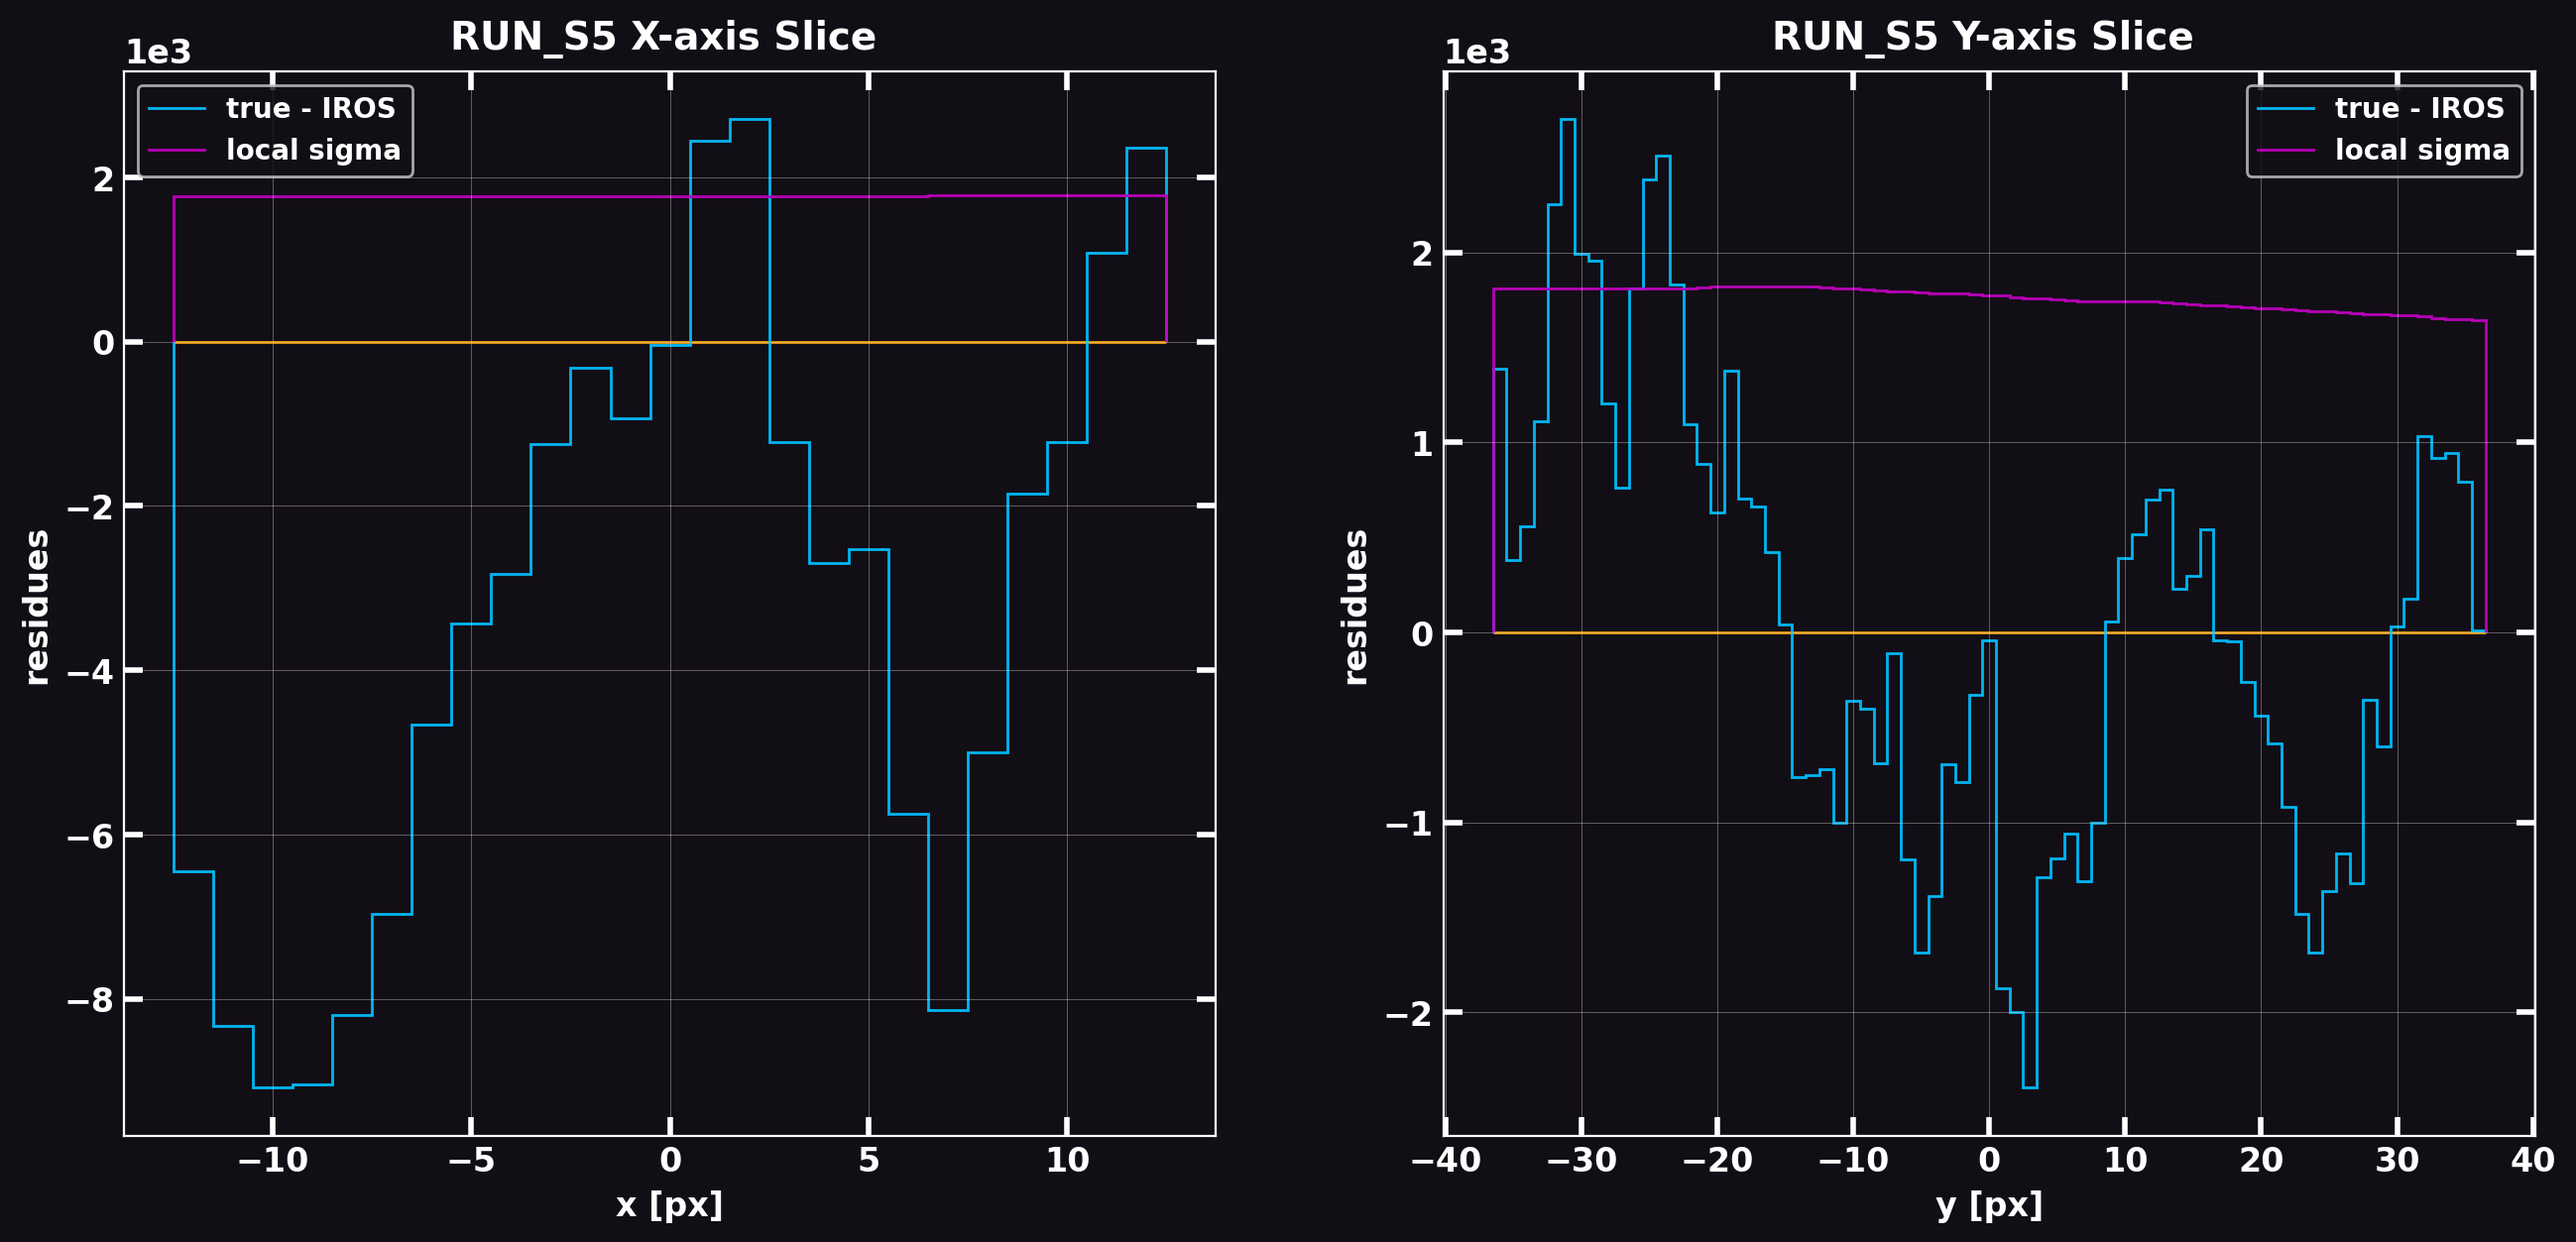

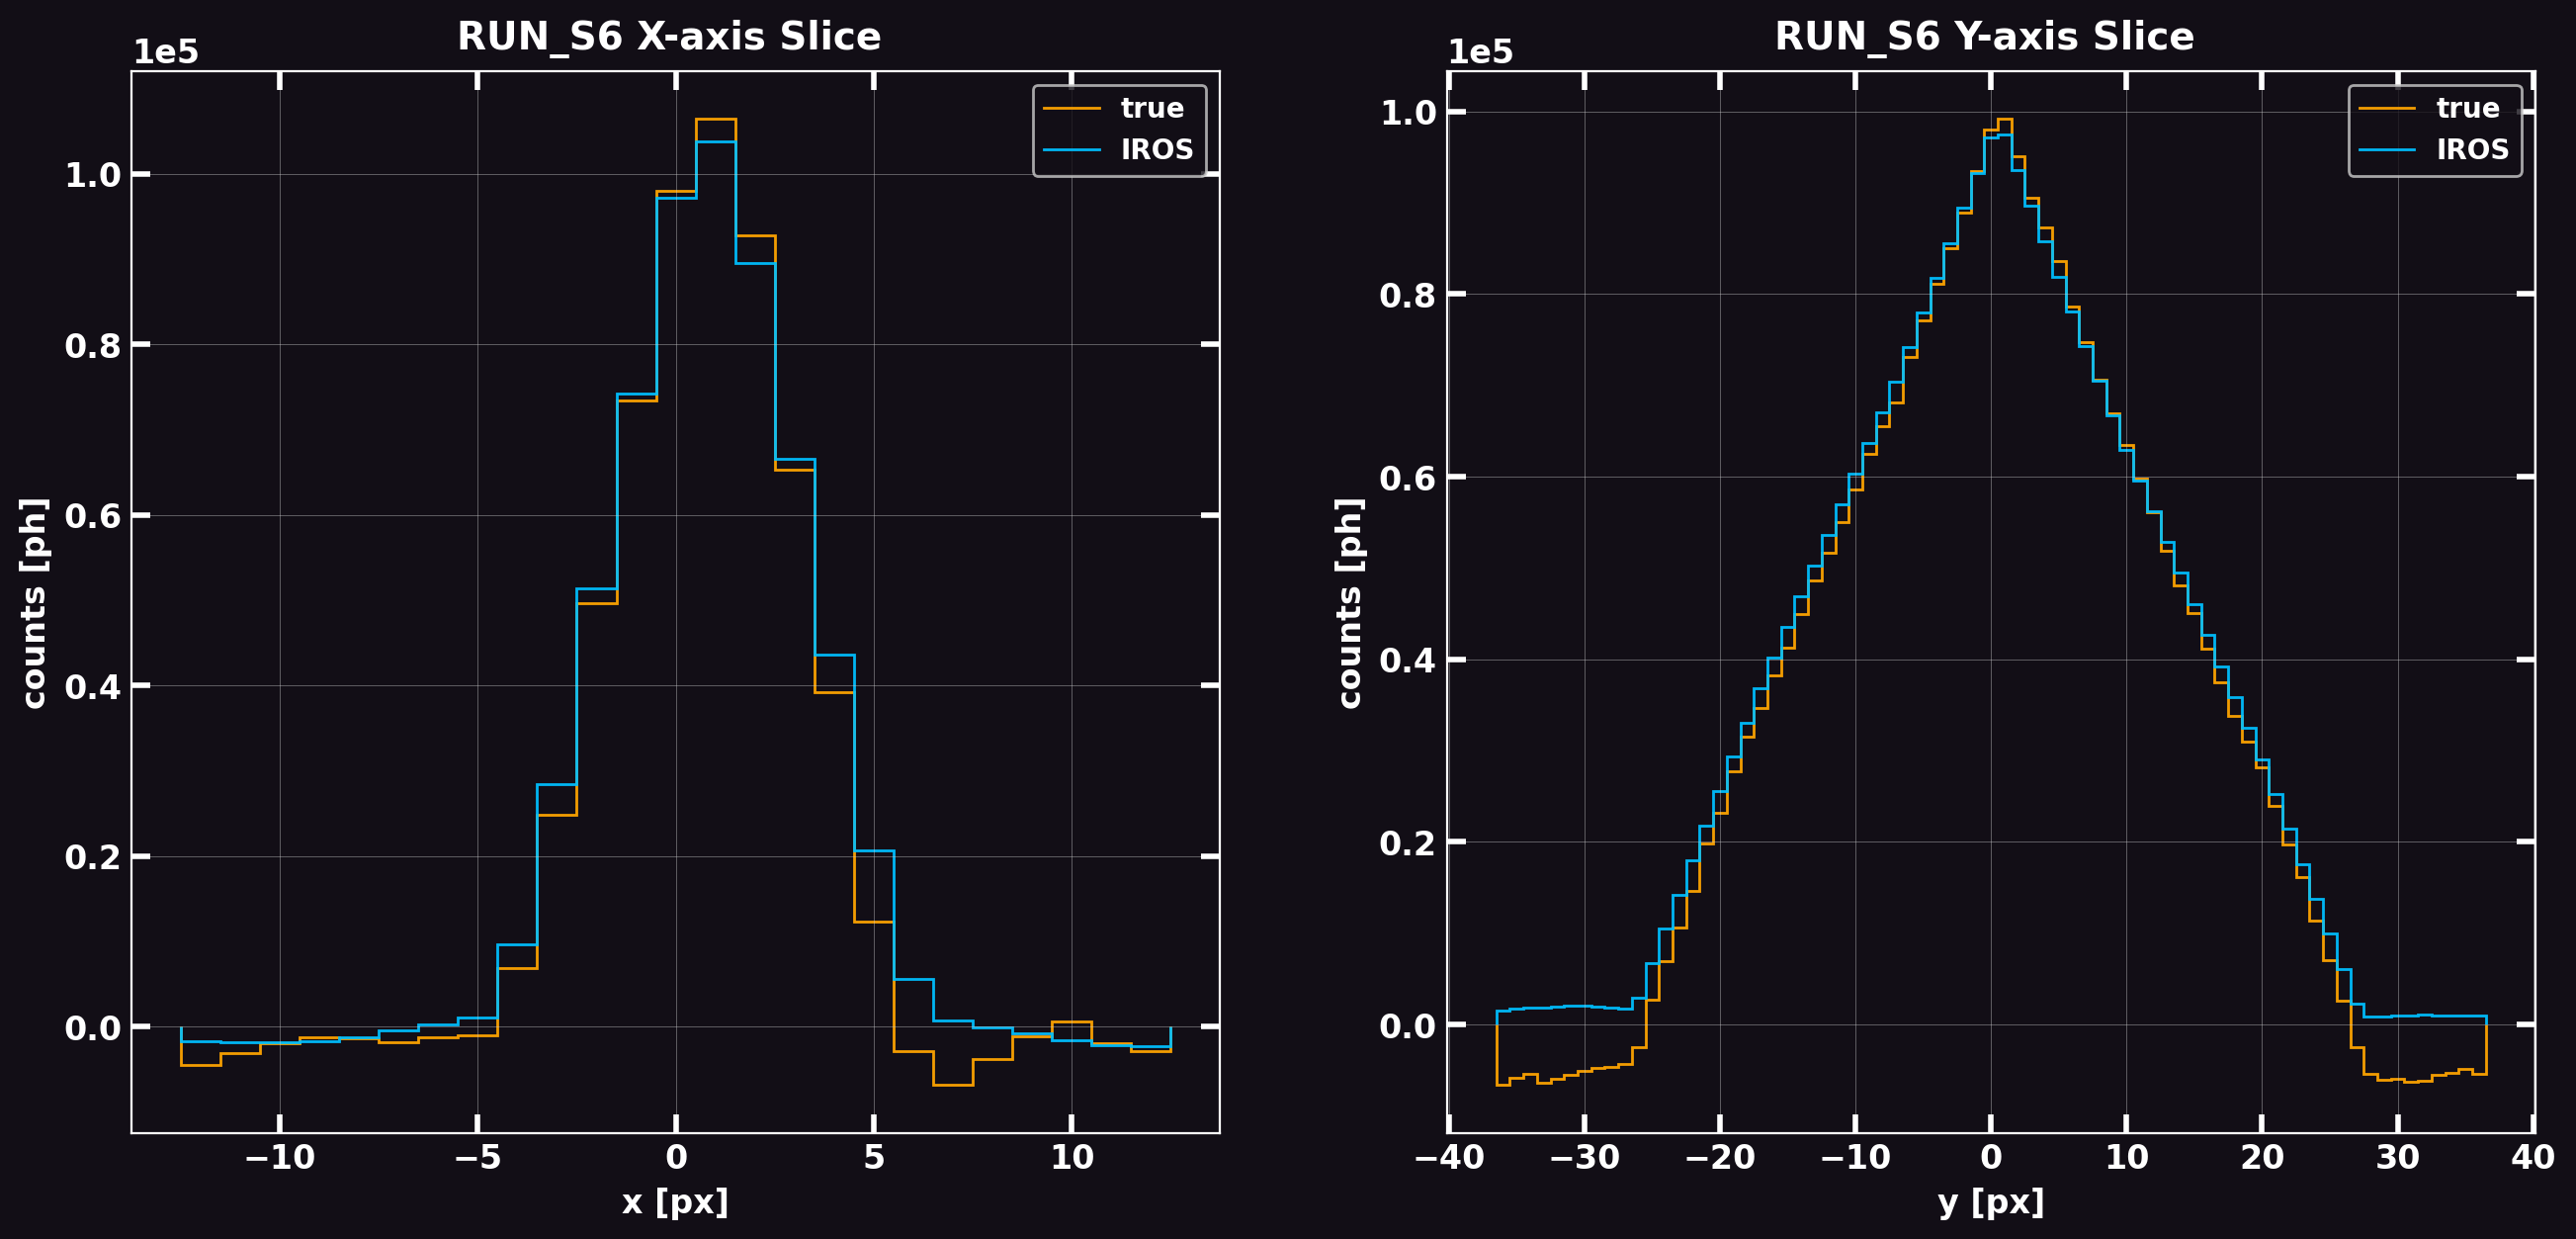

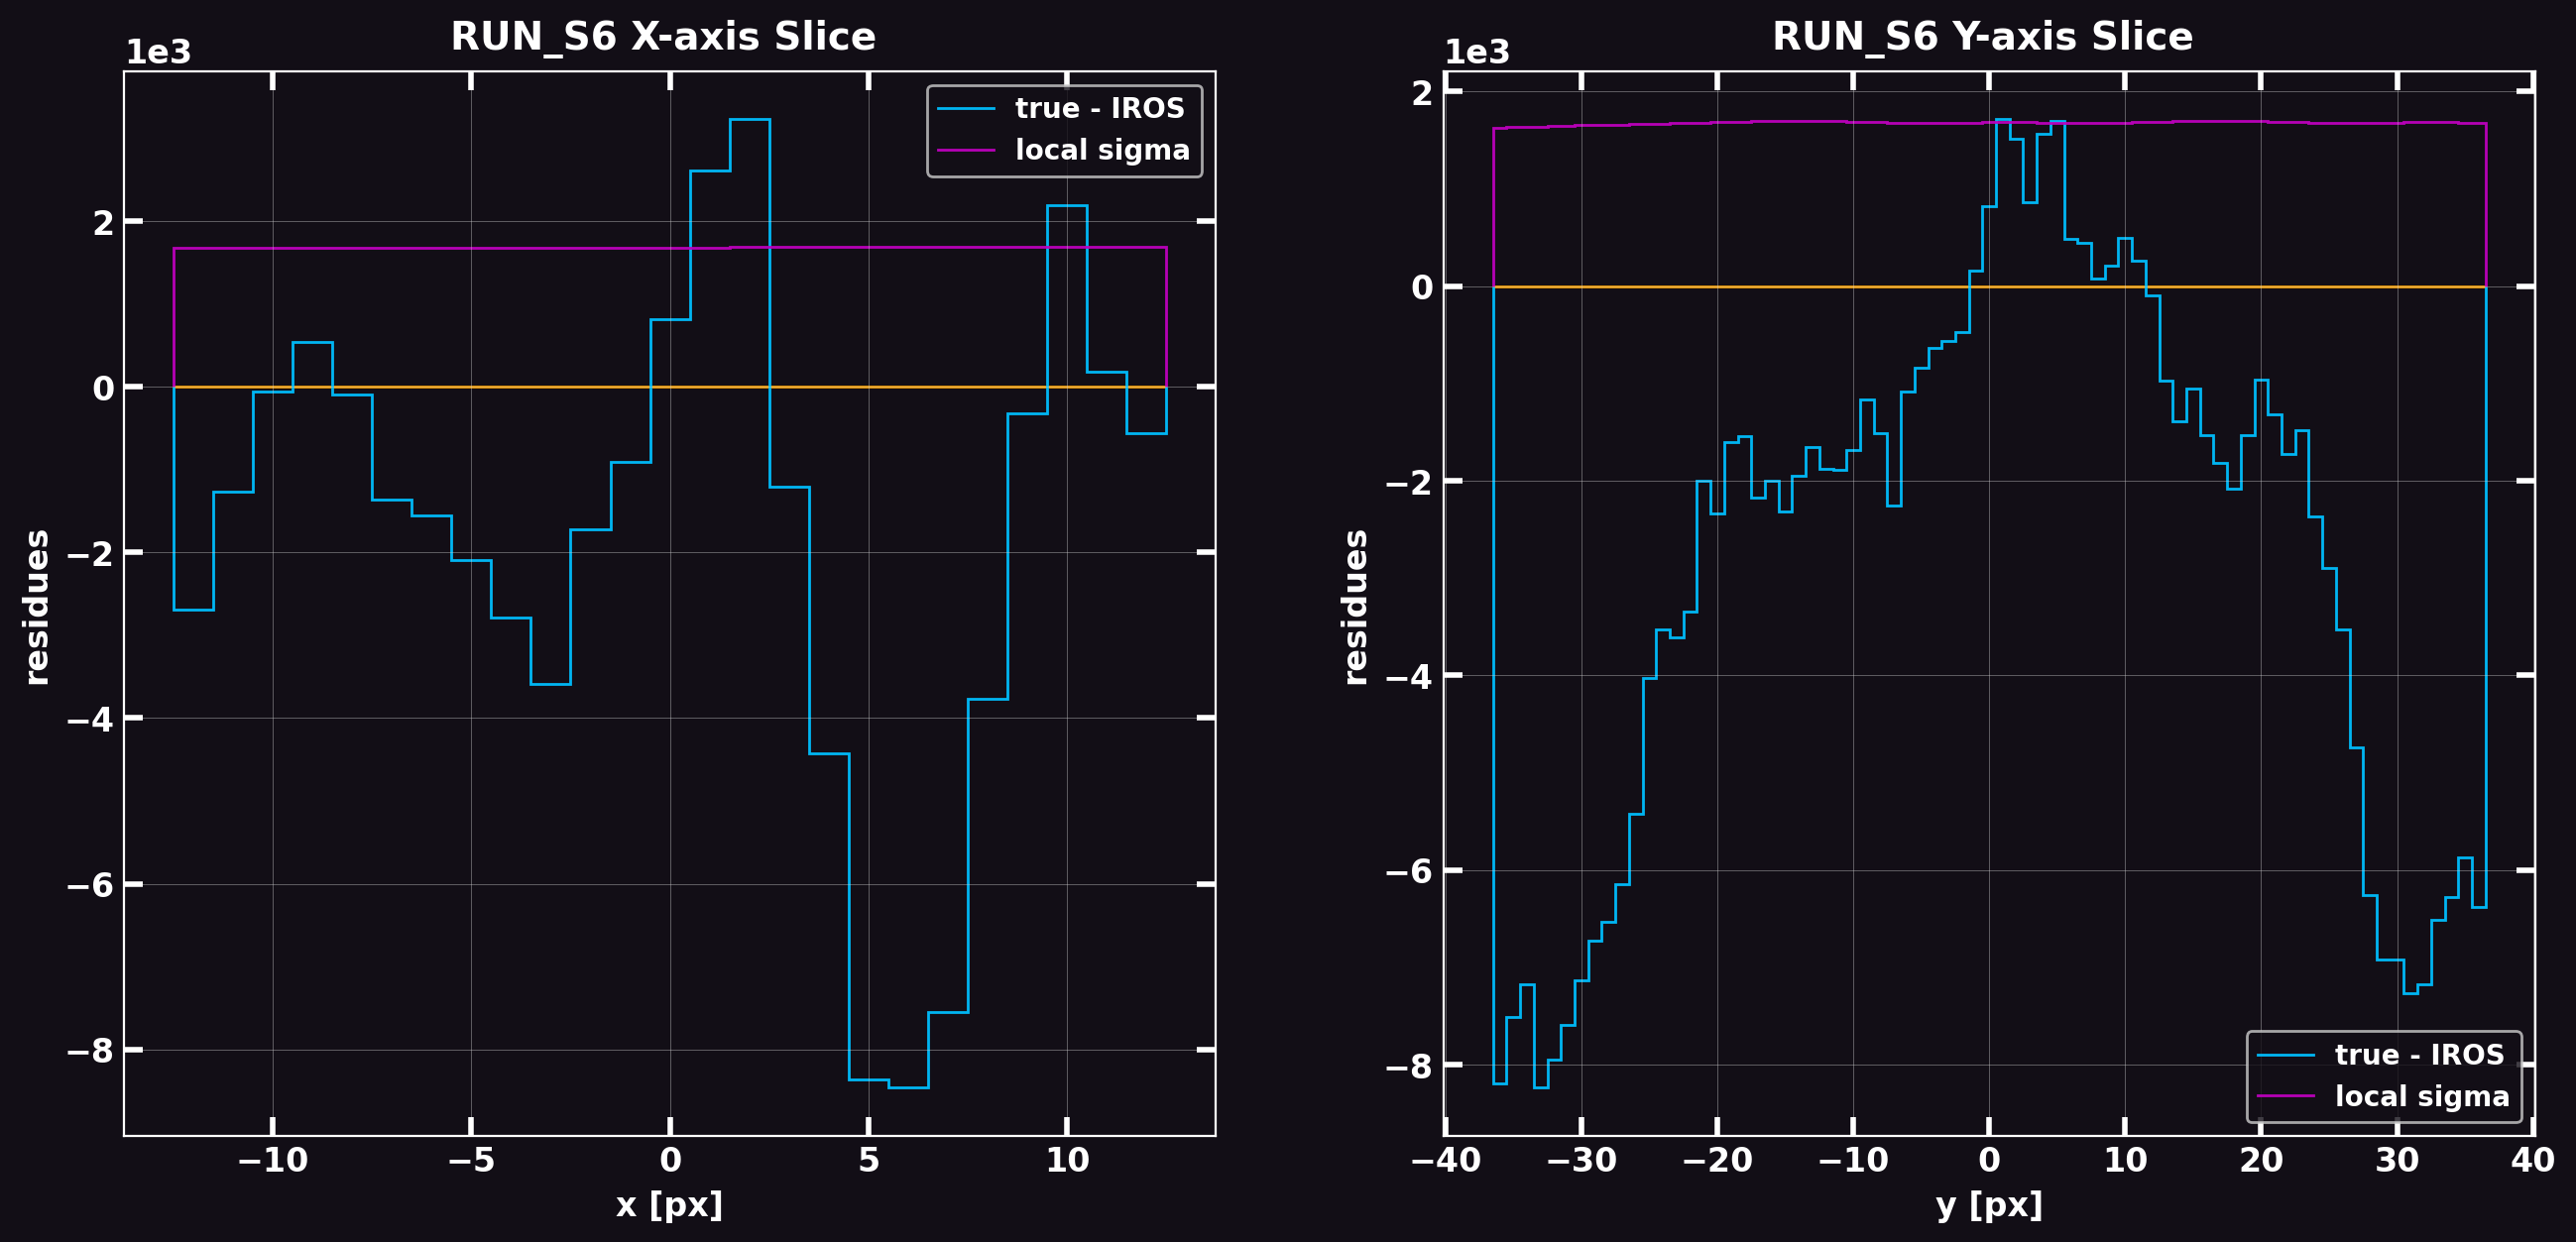

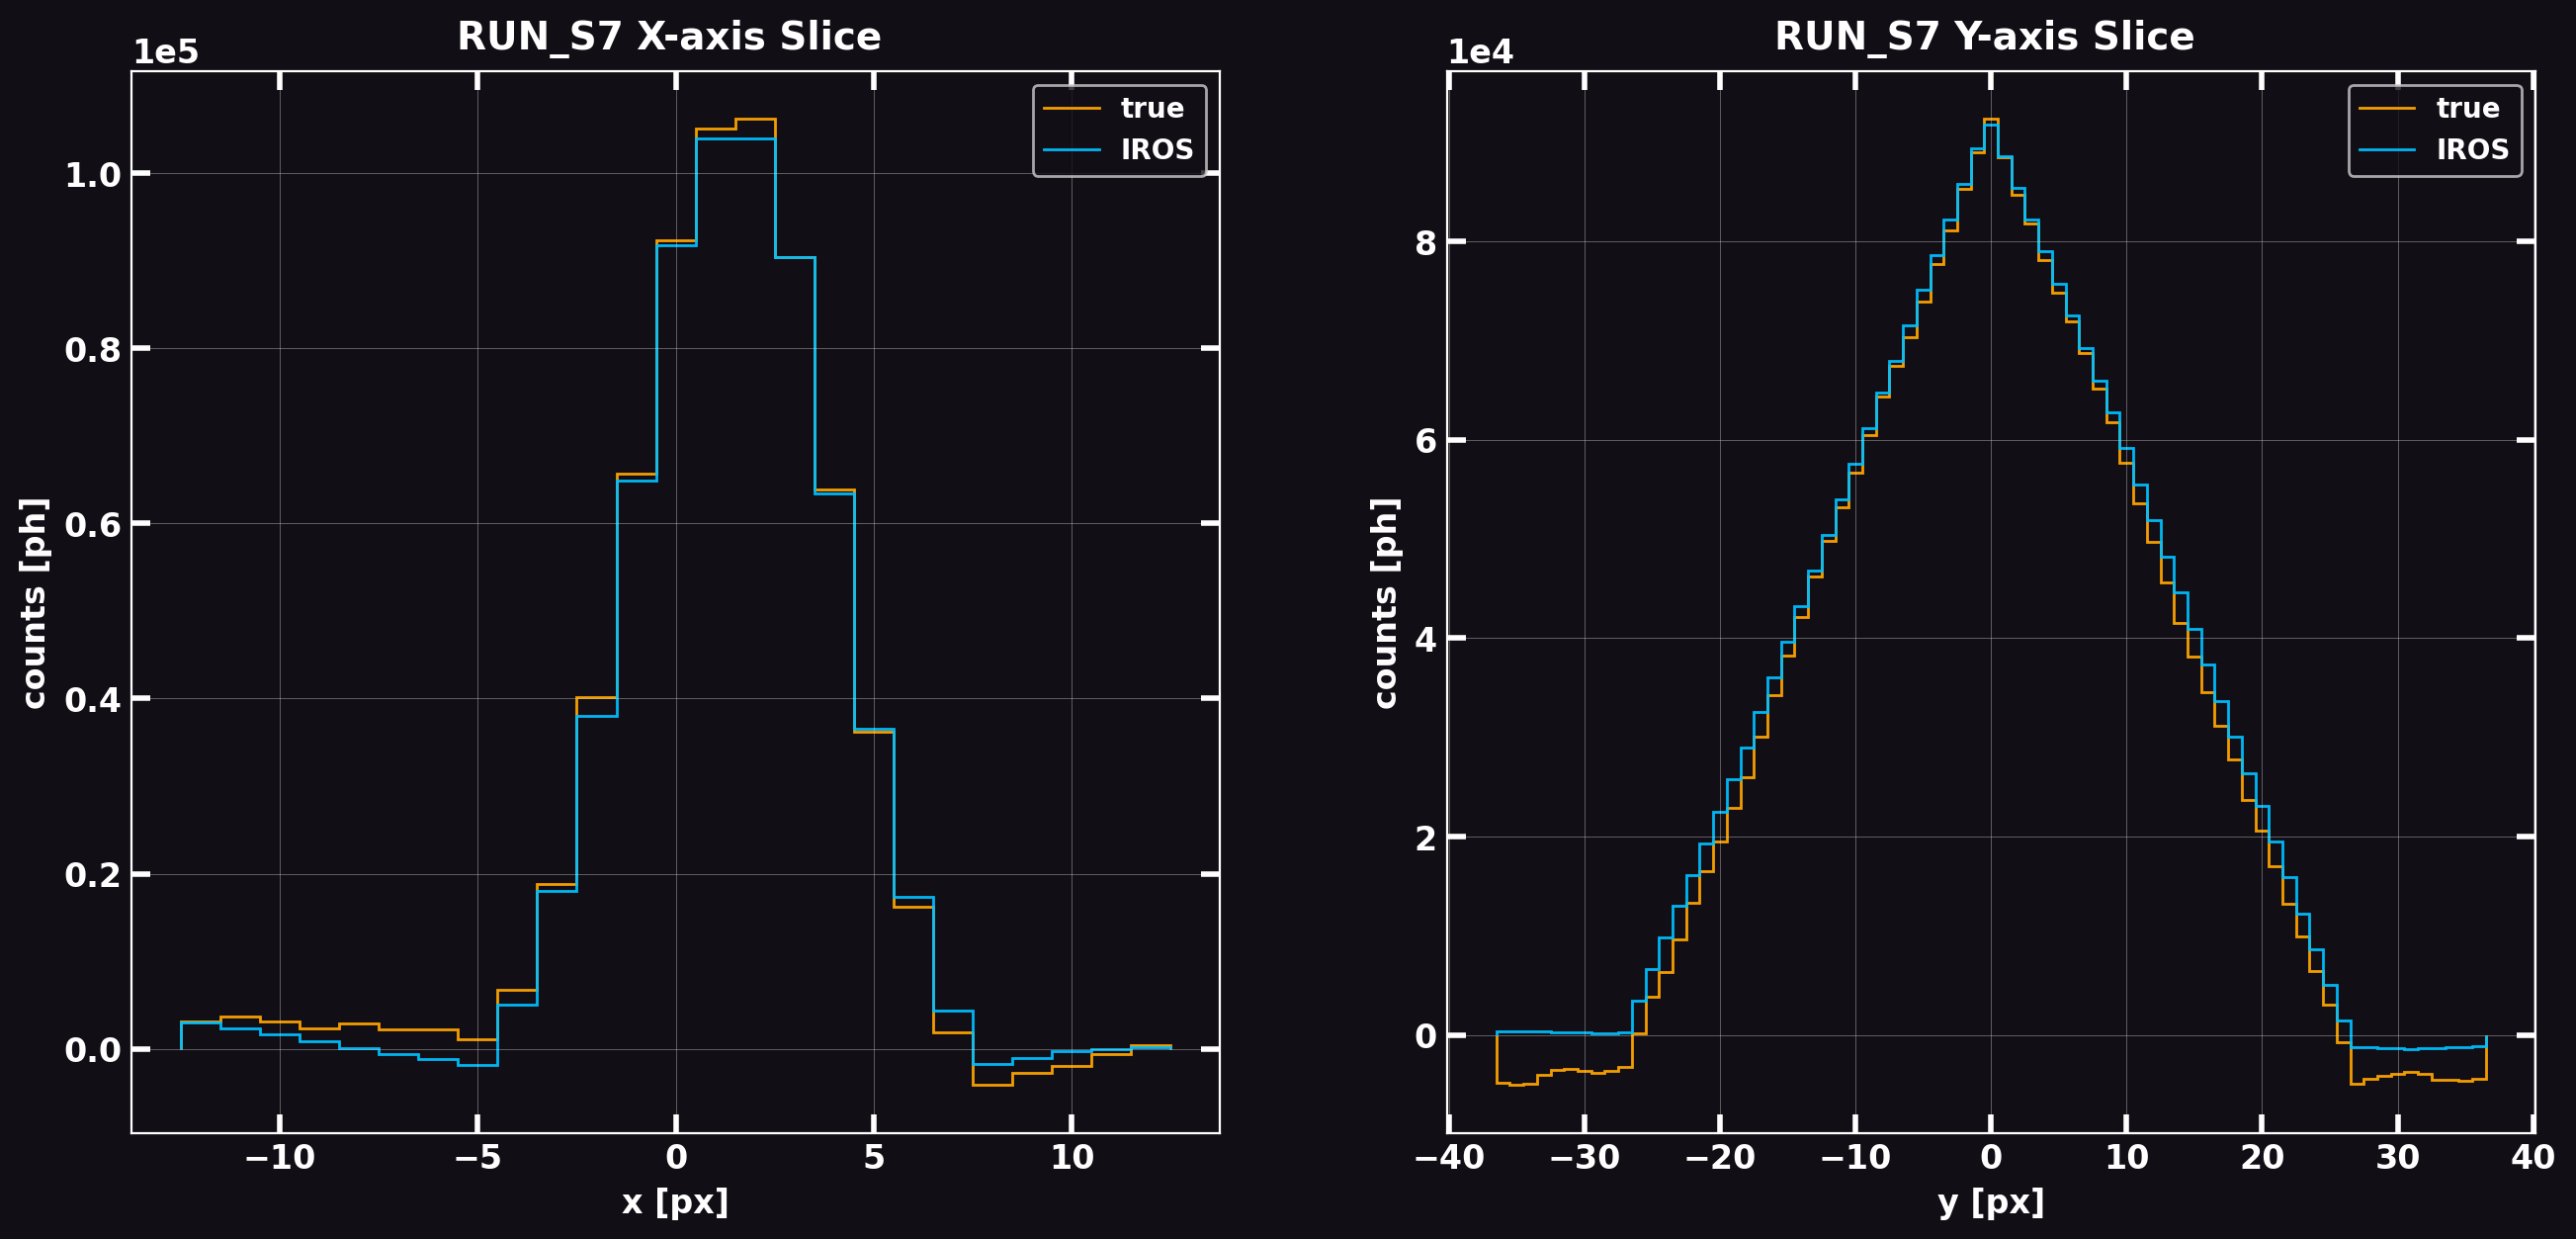

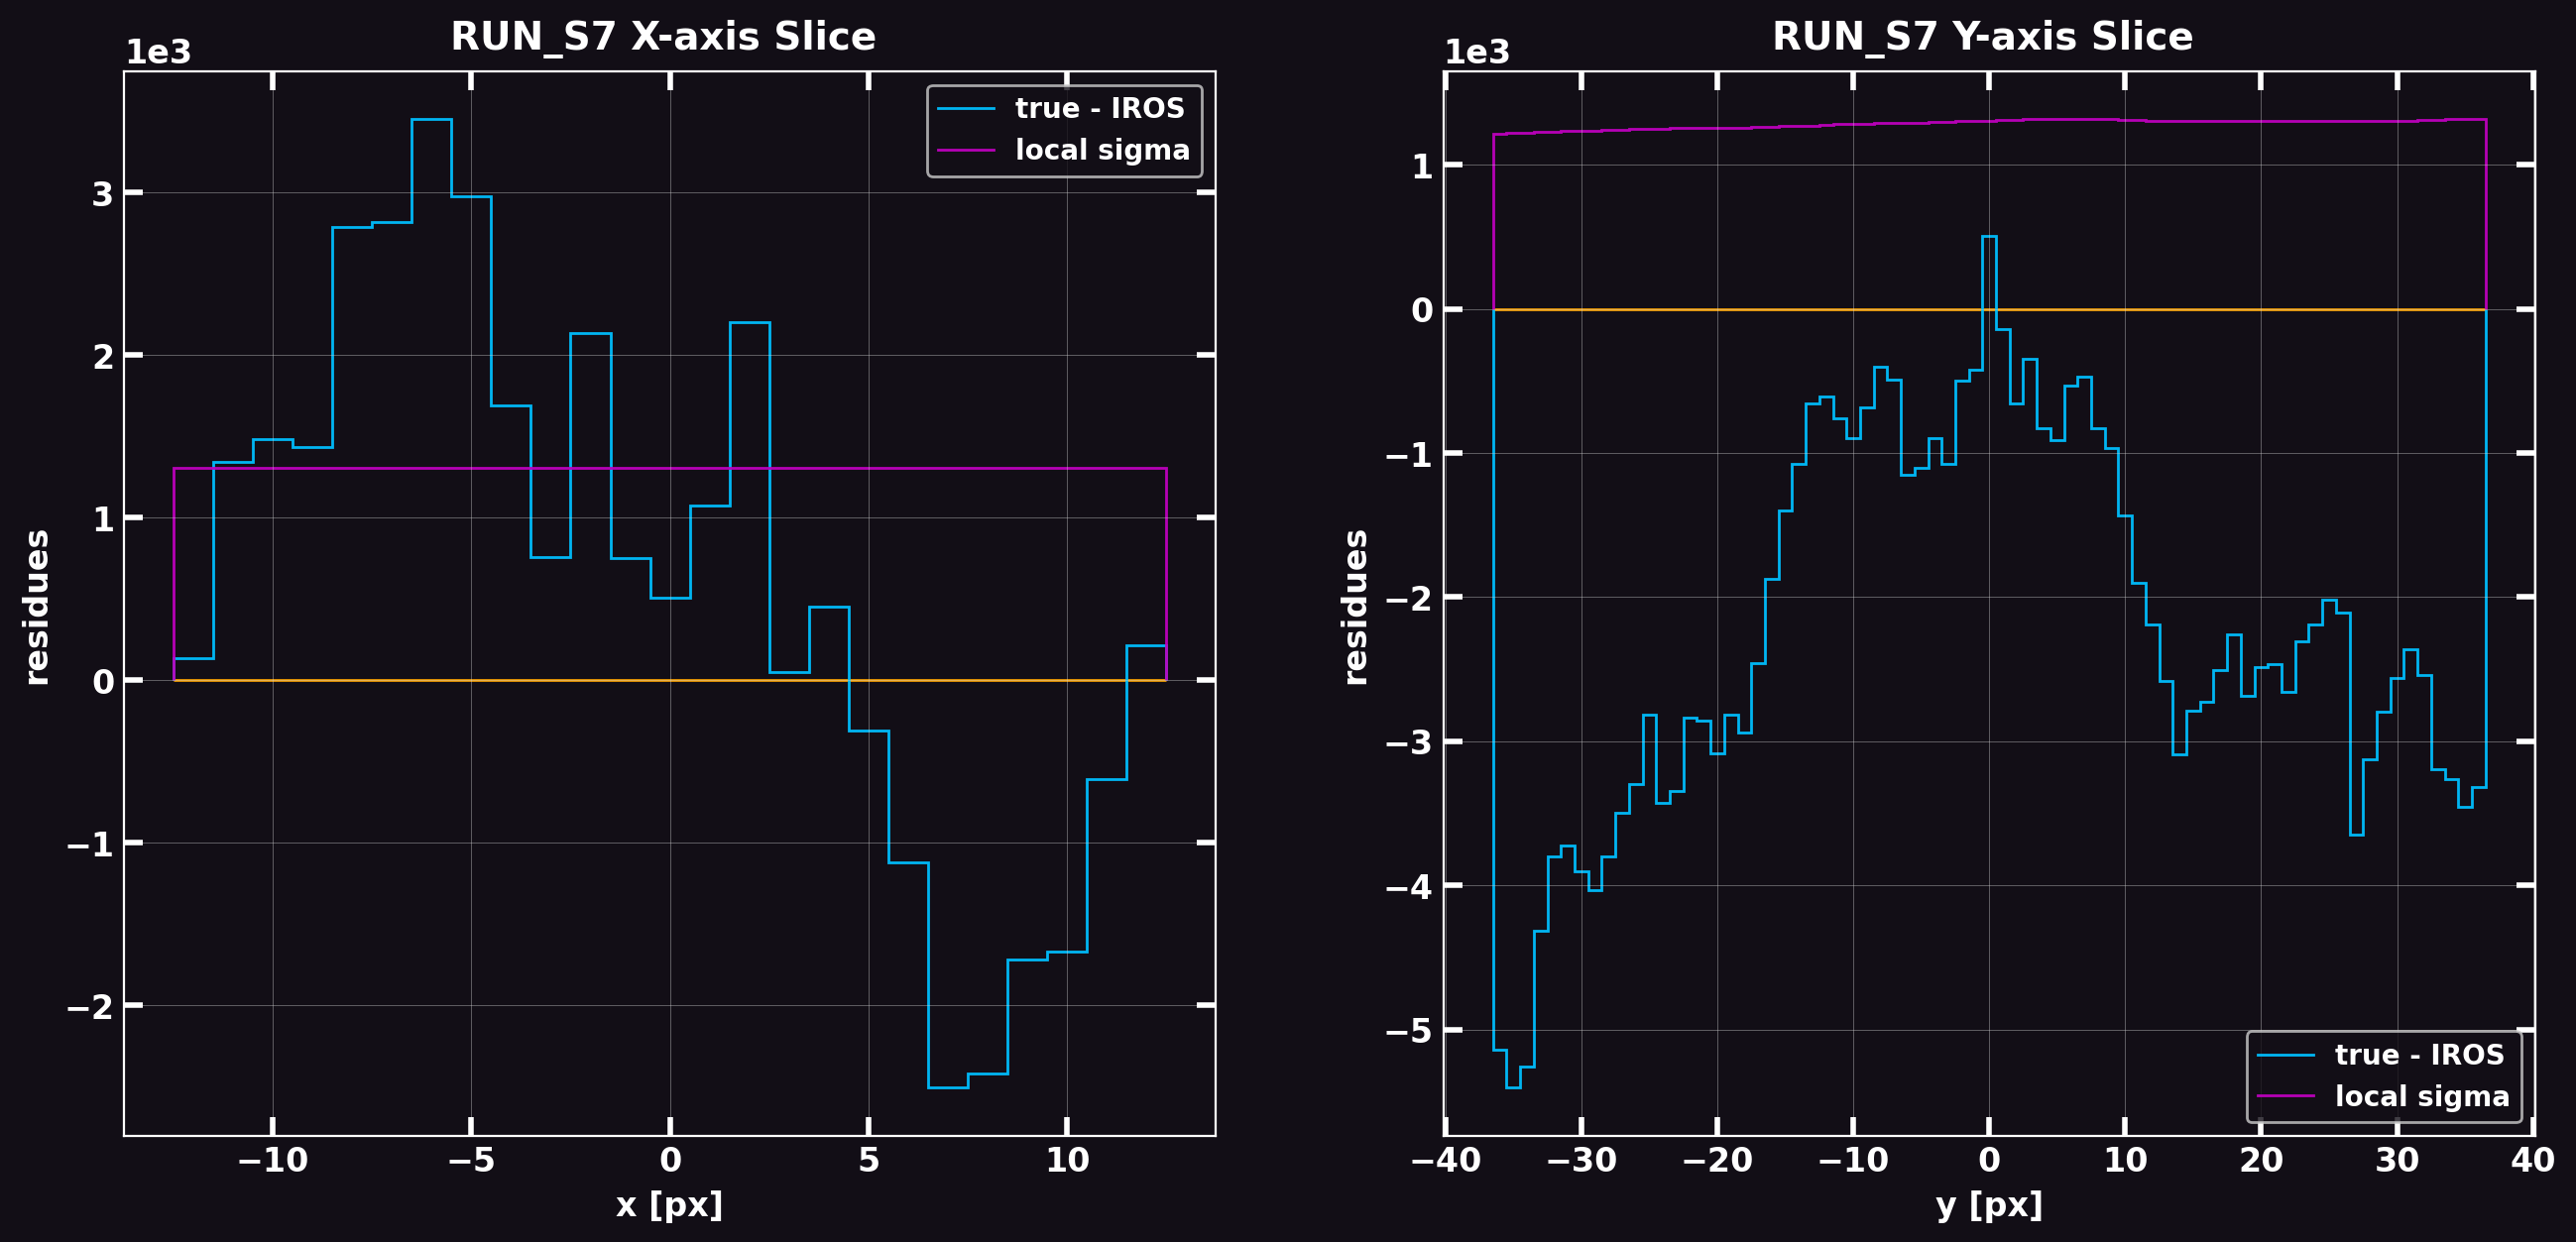

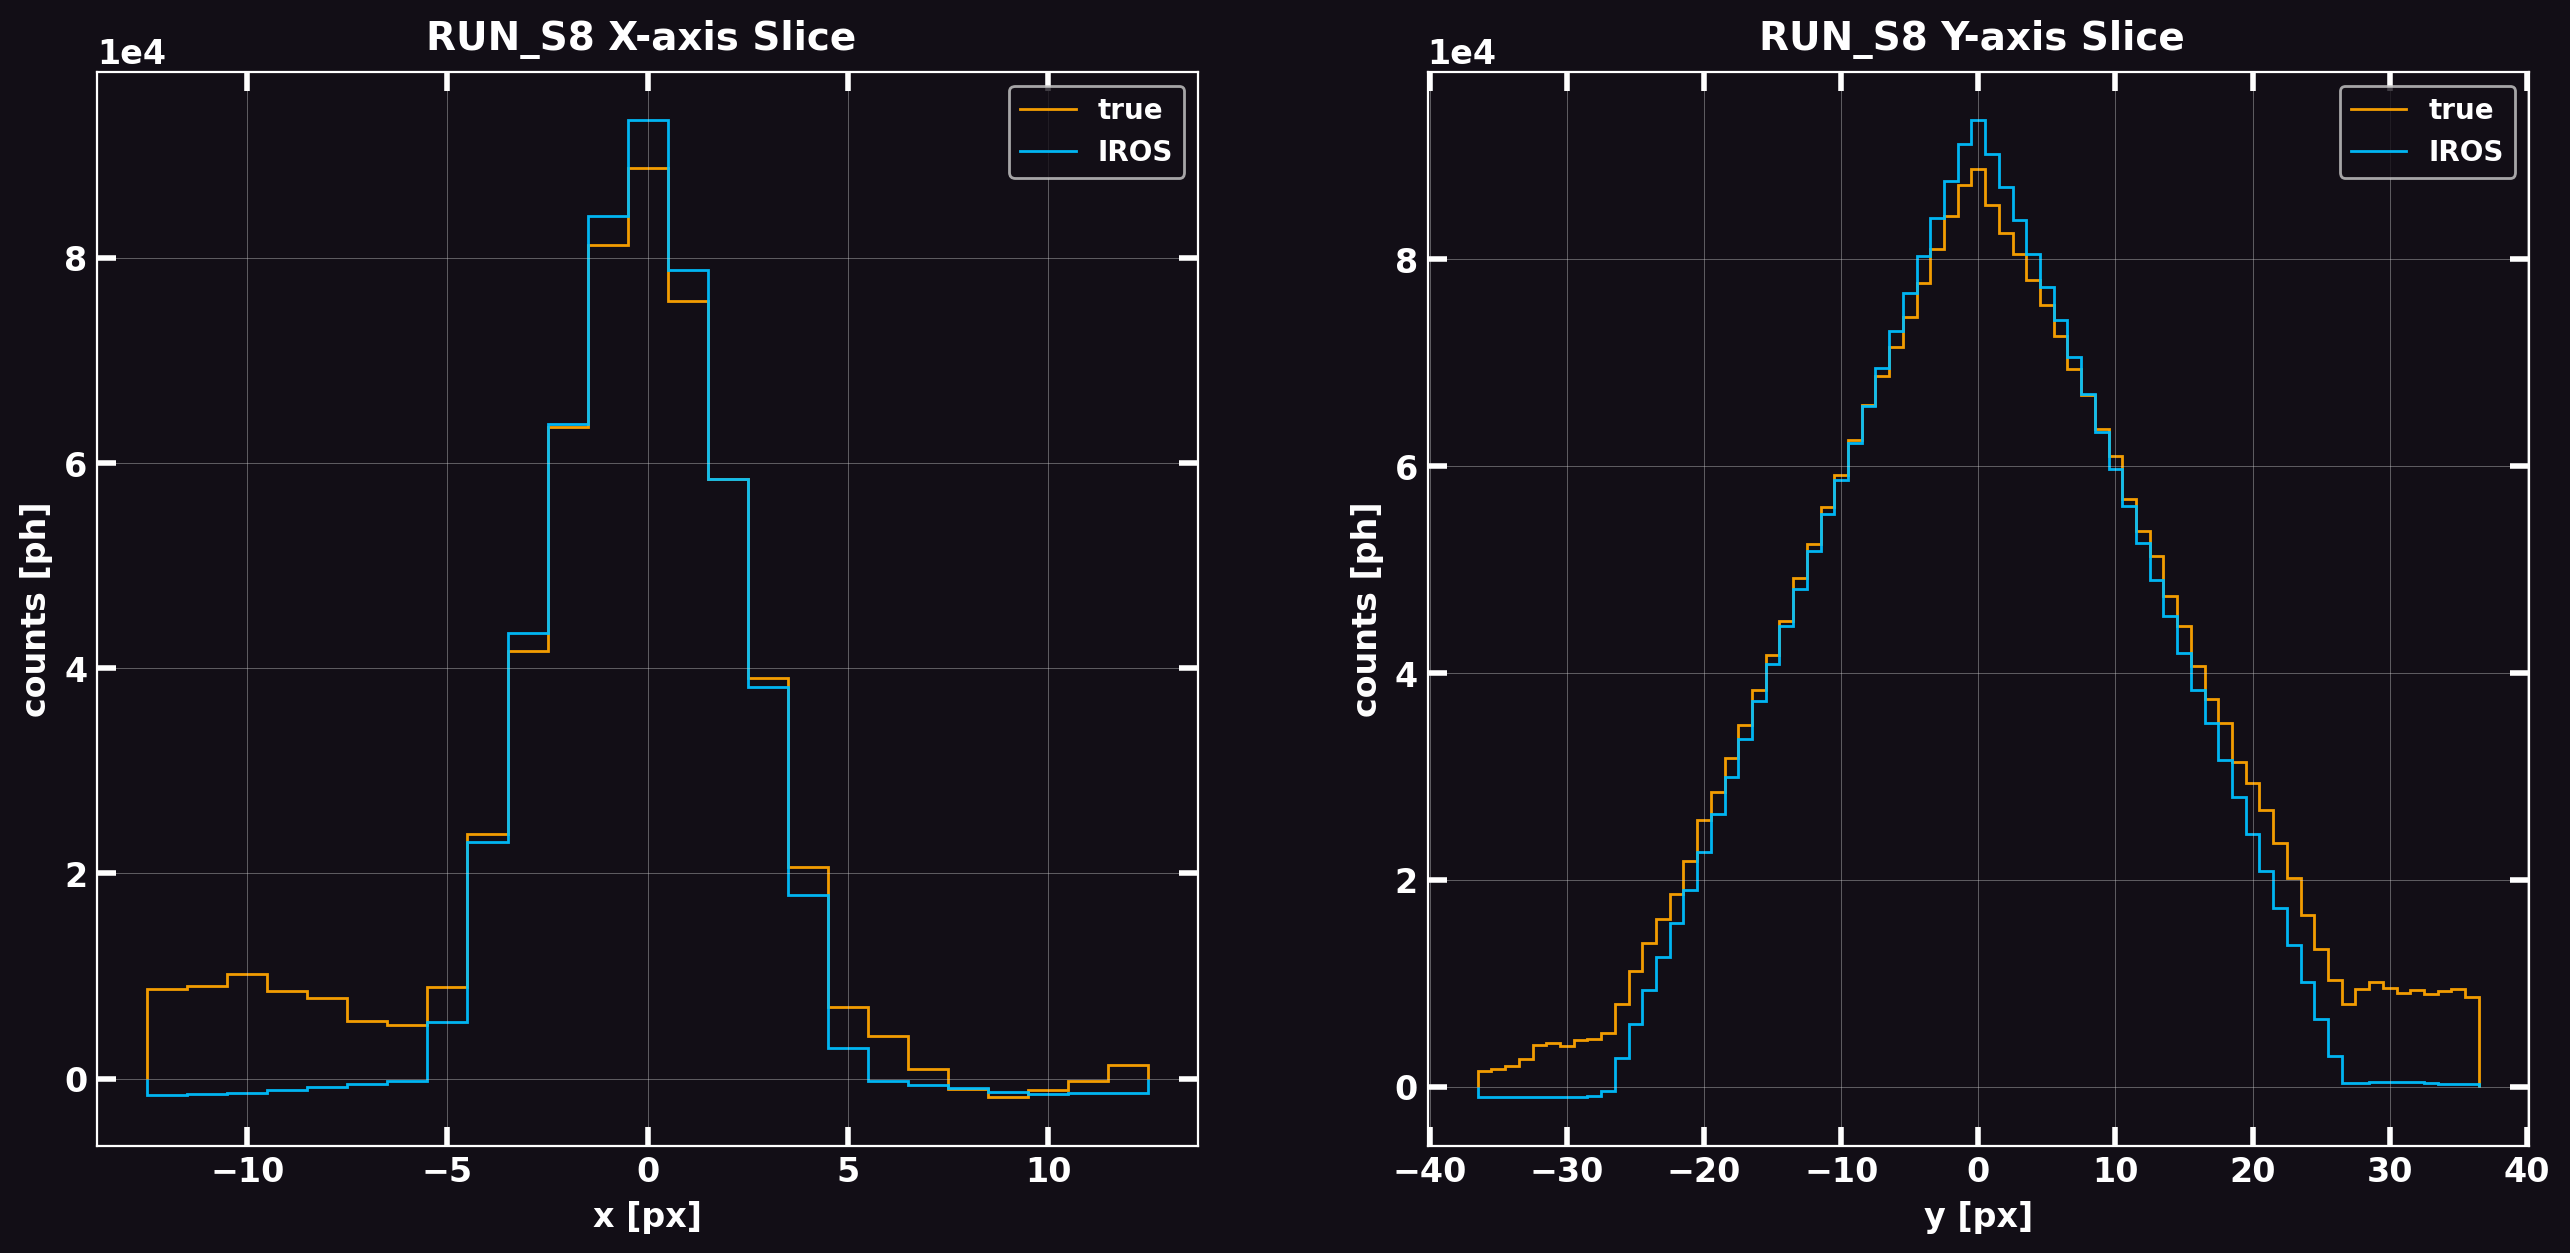

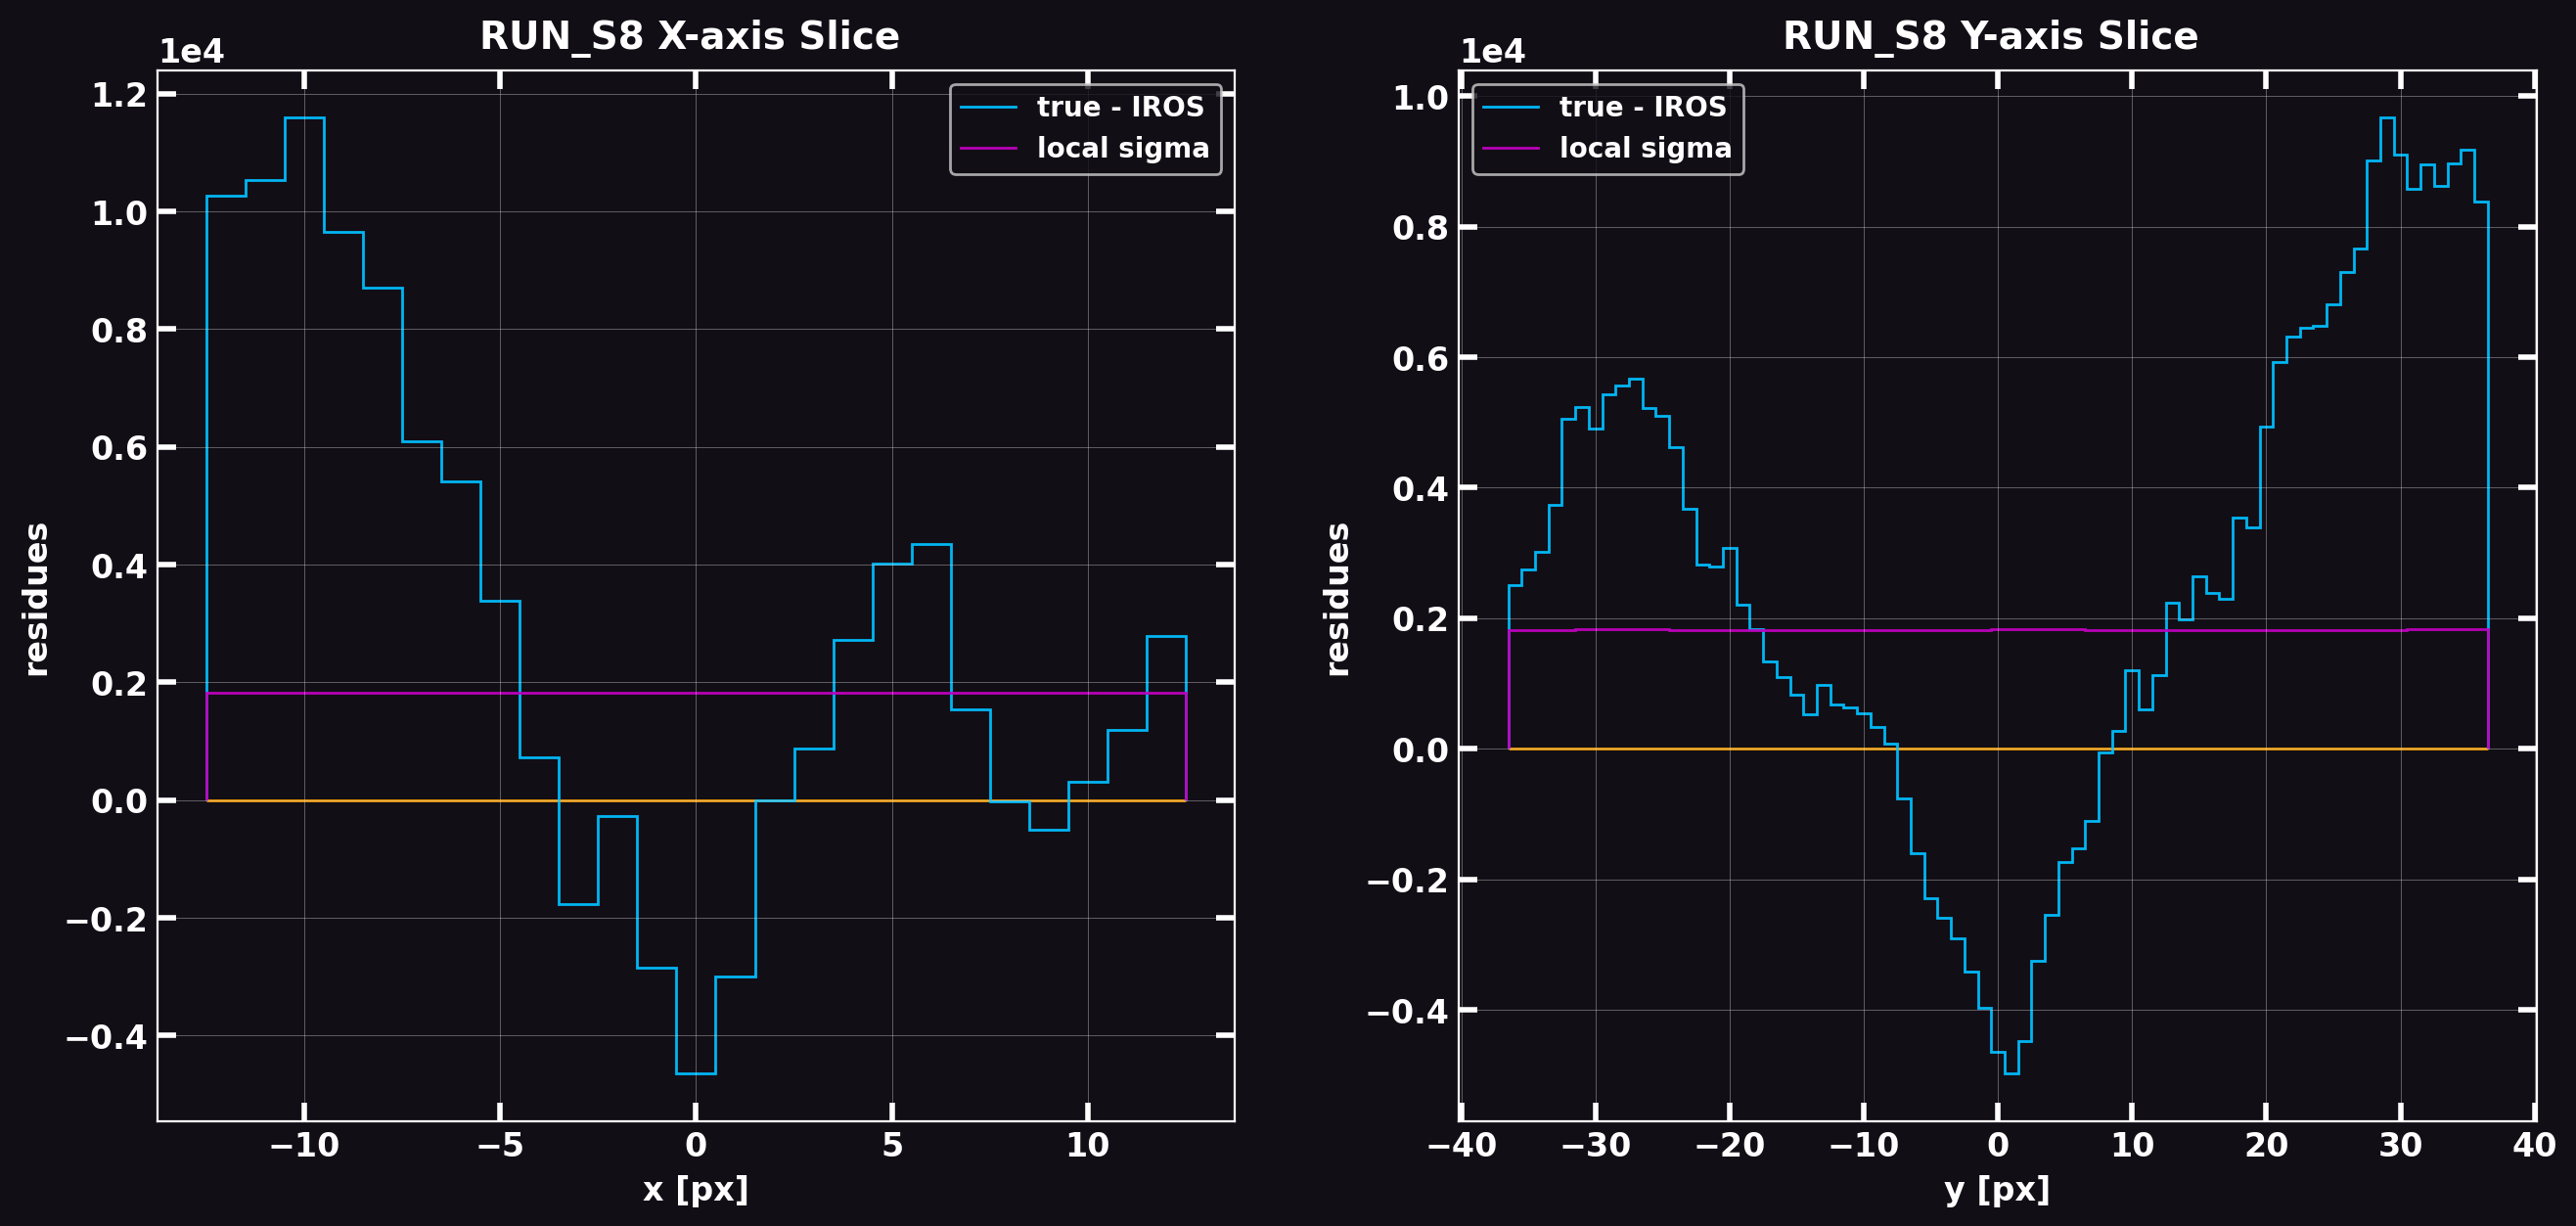

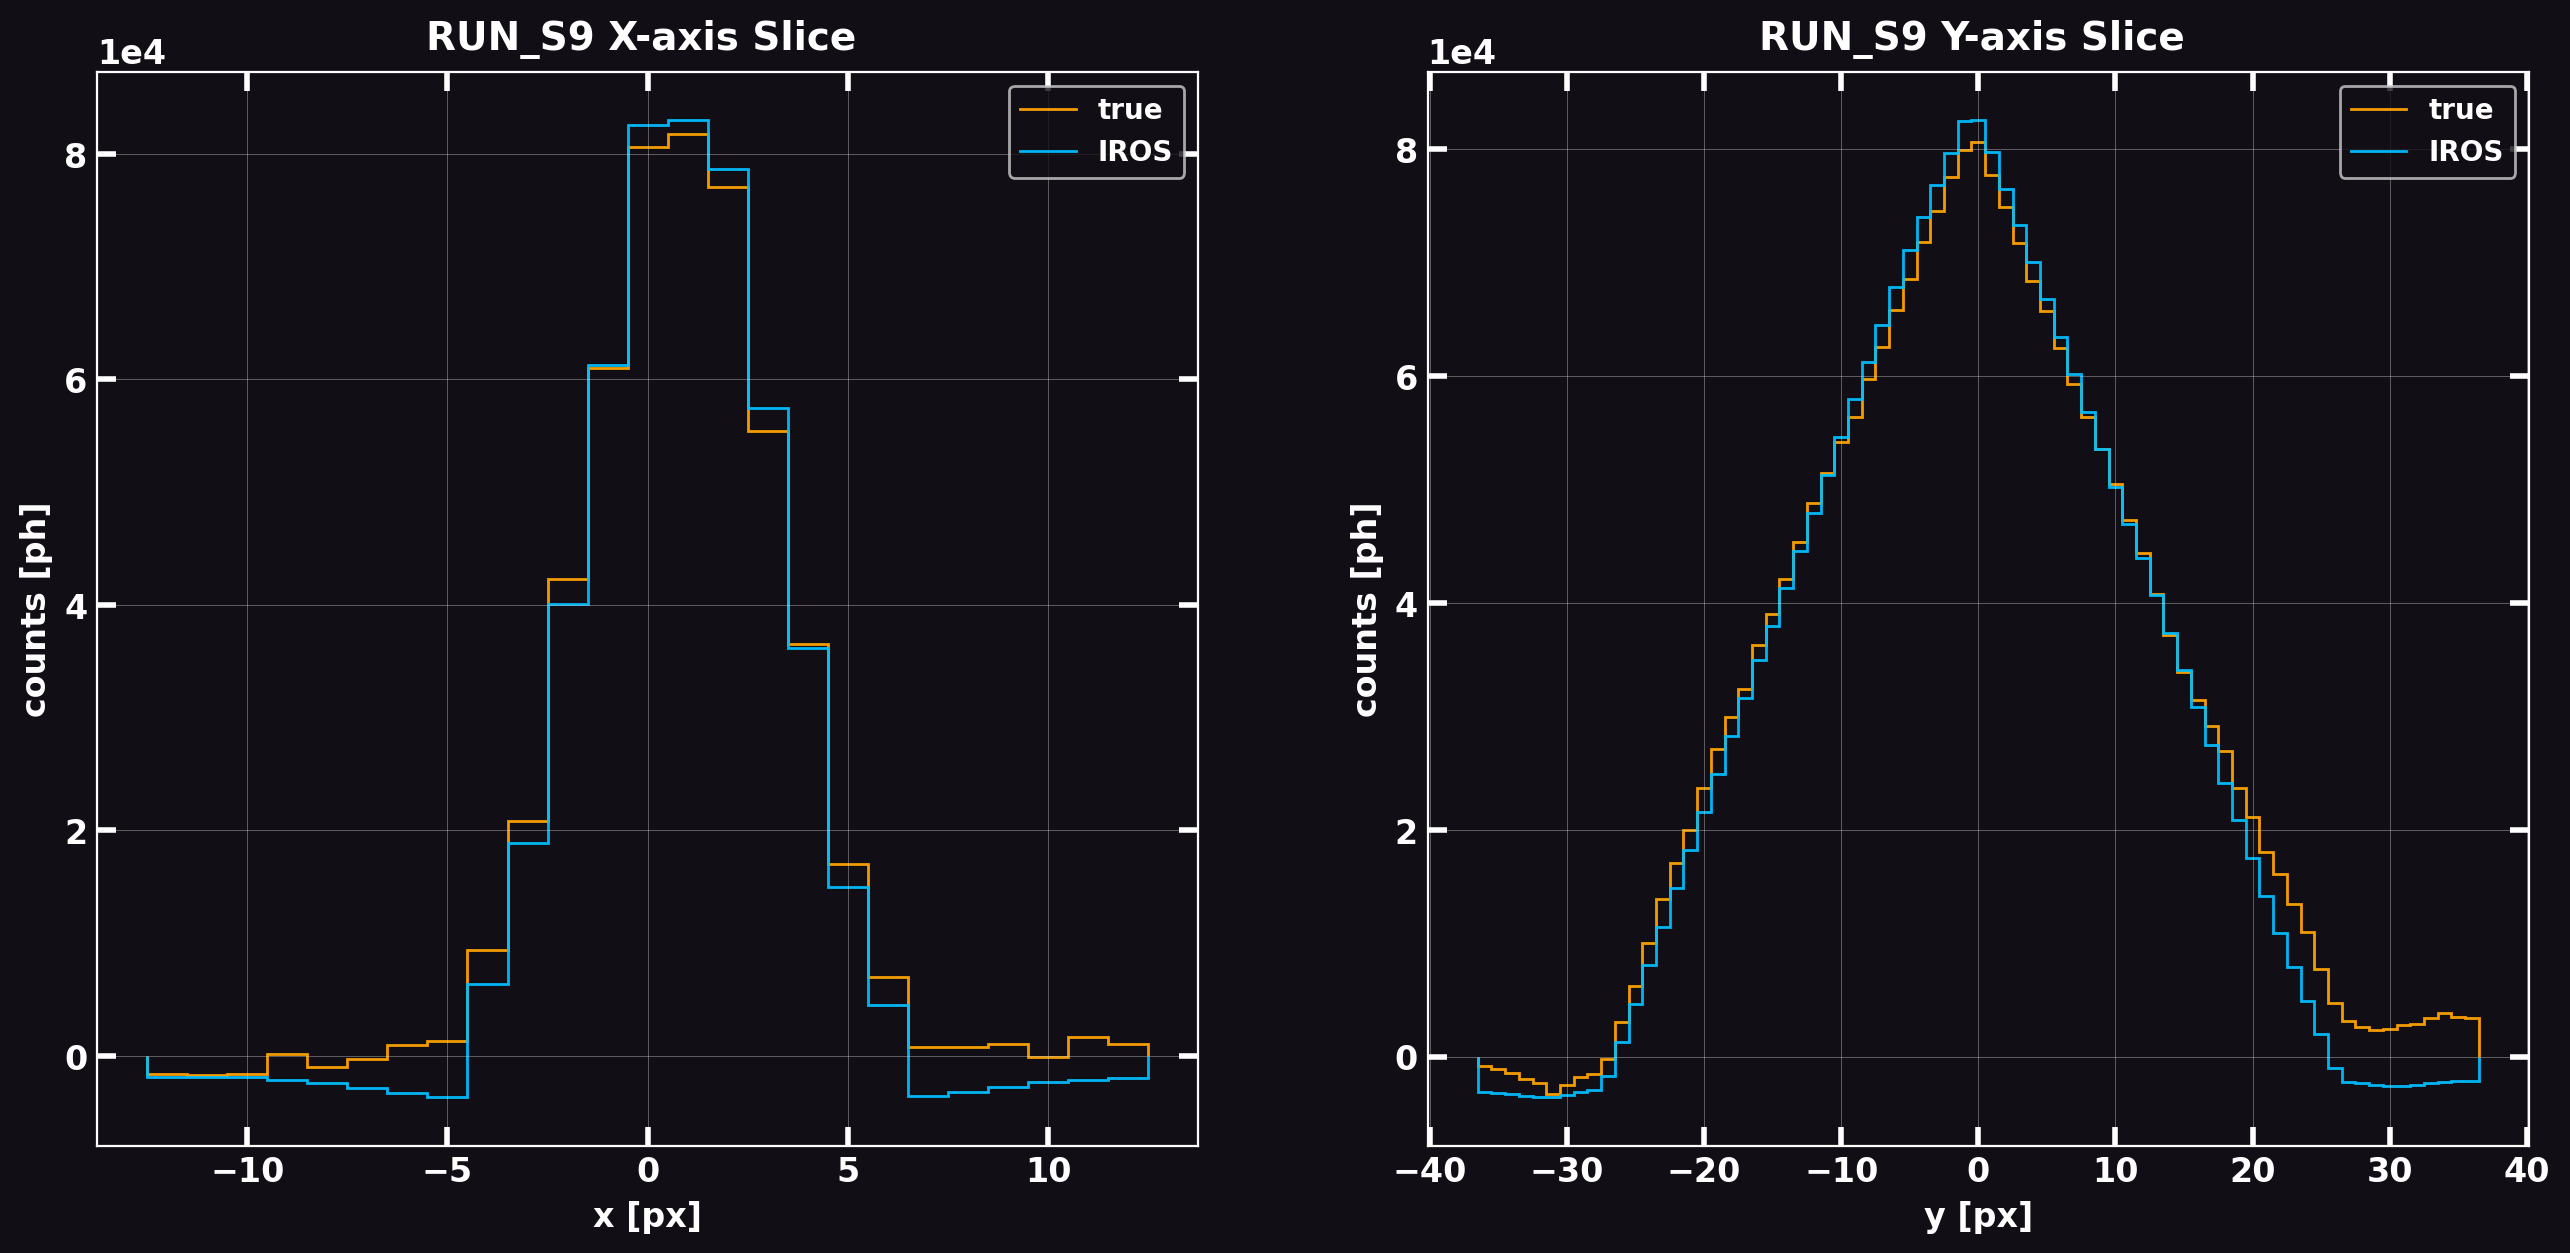

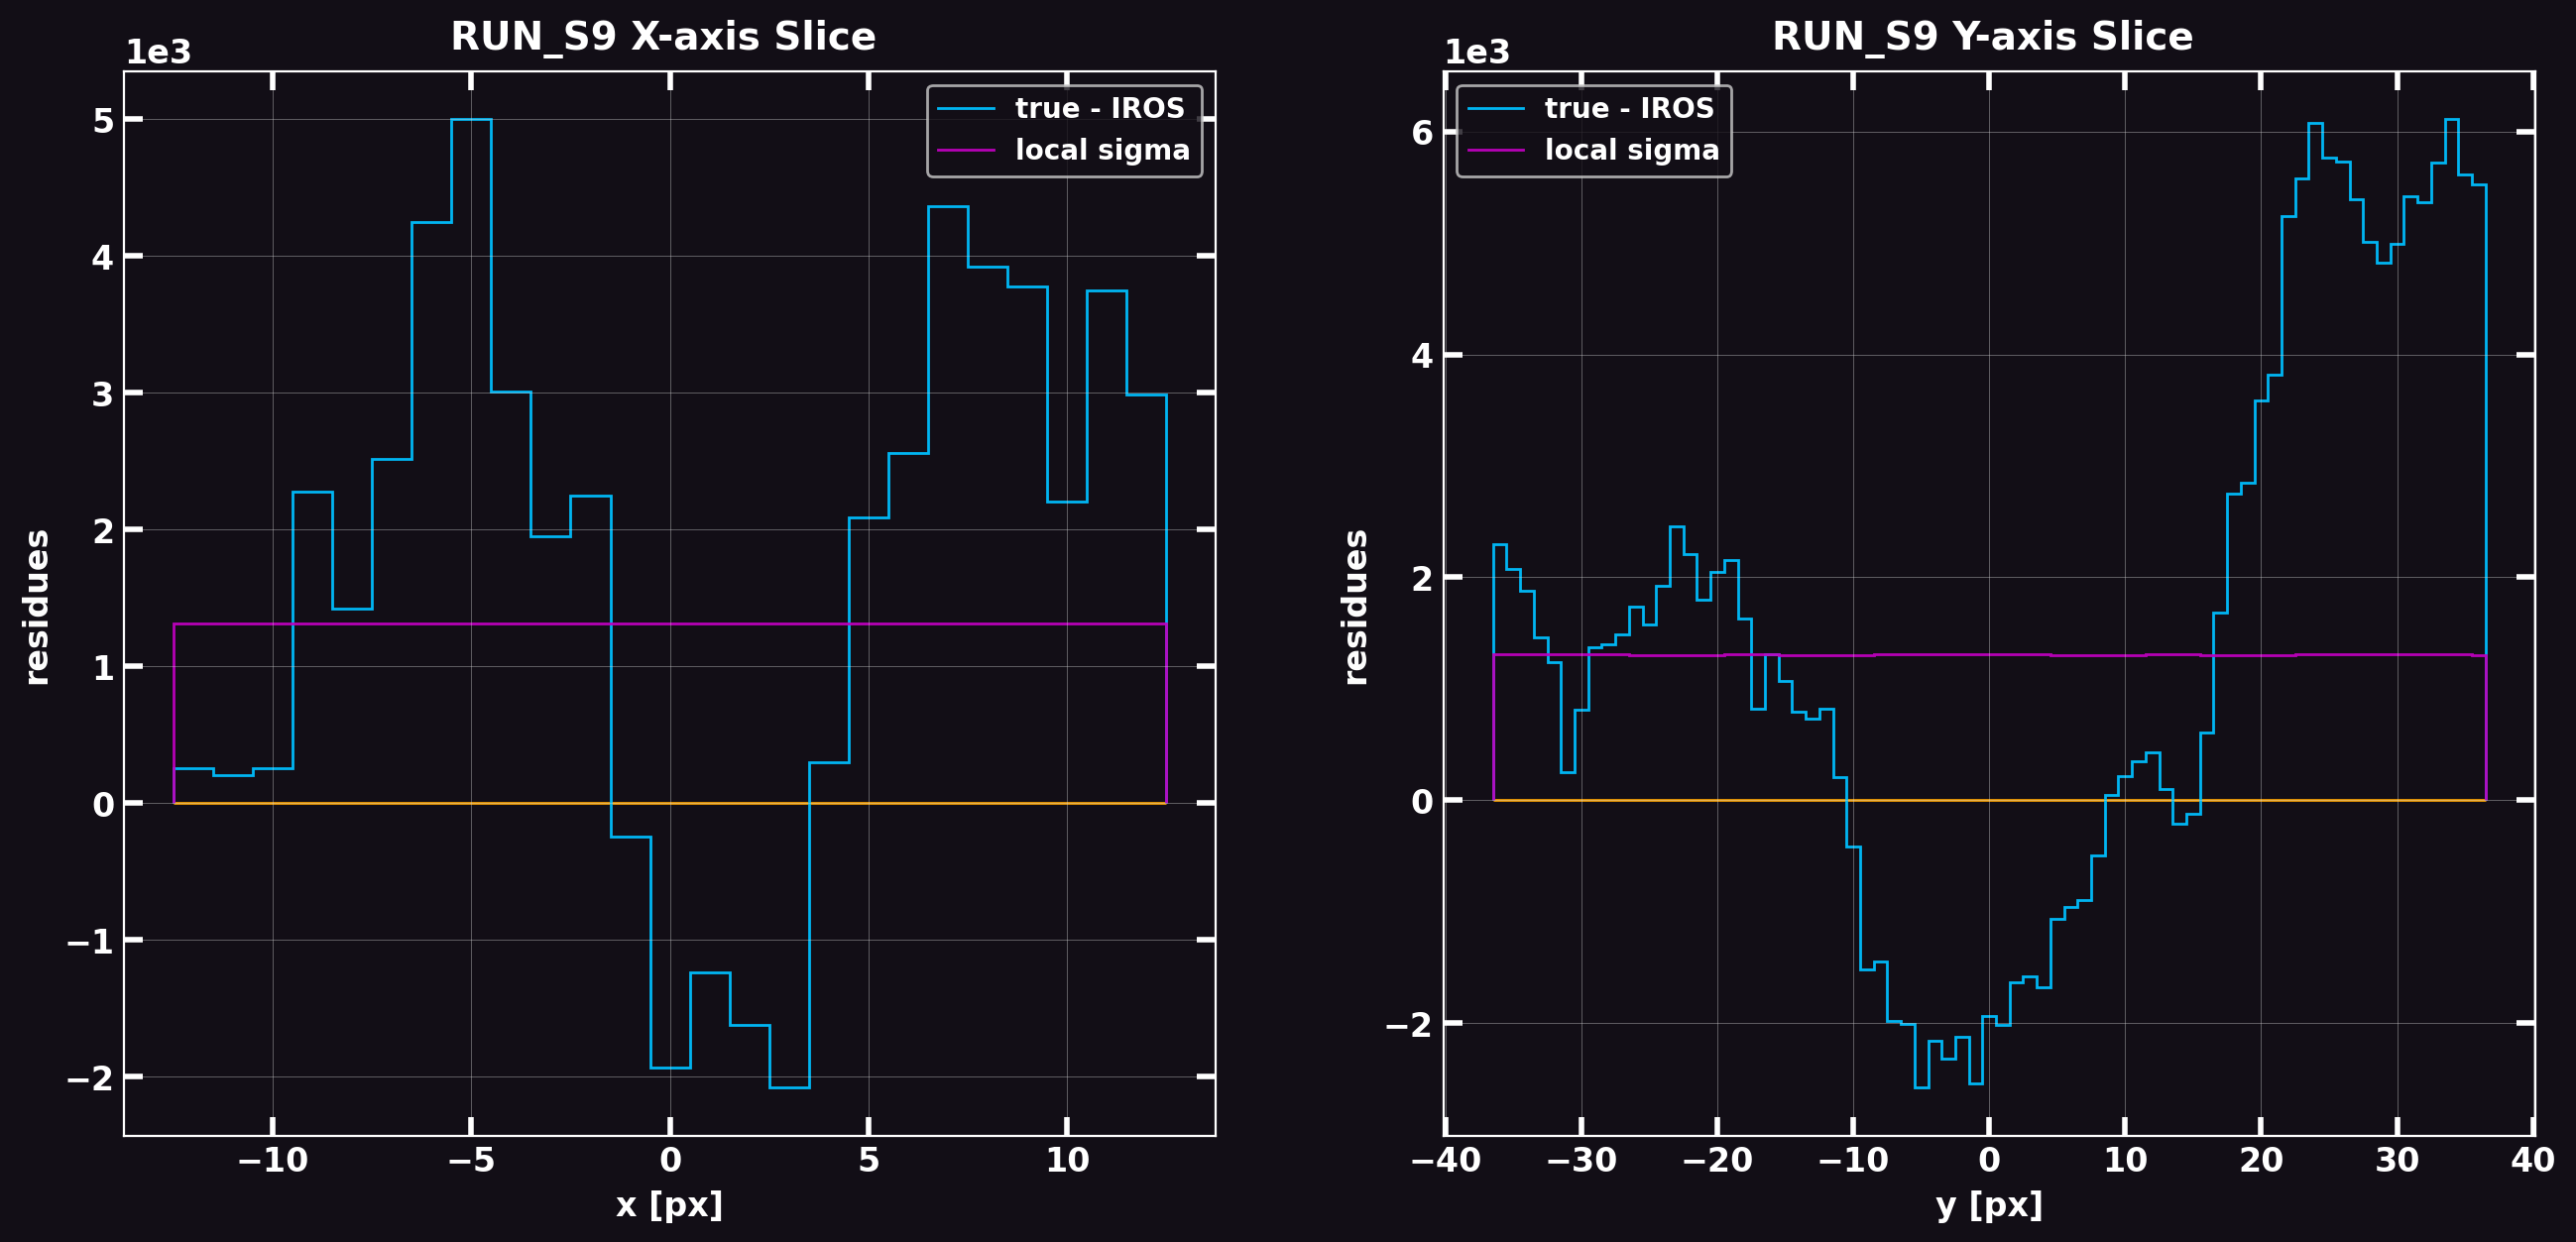

In [6]:
# WITHOUT SIGMA
from bloodmoon.mask import decode
from bloodmoon.mask import variance

true_sky: NDArray = decode(wfm, detector)
varmap: NDArray = variance(wfm, detector)

#save_to = '/home/edoardo/Desktop/ebands_IROS_run'
save_to = '/mnt/d/PhD_AASS/Coding/Images_fits/tests_results/reconstructed_noErrors'
plot_results(true_sky, candidates, wfm, varmap=varmap, save_to=None)